In [35]:
import os
import mlflow
import platform
import pandas as pd

# 🛠️ WINDOWS COMPATIBILITY LAYER
# Fixes the 'missing experiments' bug in MLflow UI
def setup_mlops():
    base_dir = os.getcwd().replace(os.sep, '/')
    uri = f"file:///{base_dir}/mlruns"
    mlflow.set_tracking_uri(uri)
    
    # Auto-fix legacy metadata slashes
    if platform.system() == "Windows":
        for r, d, f in os.walk("mlruns"):
            if "meta.yaml" in f:
                p = os.path.join(r, "meta.yaml")
                with open(p, 'r') as file: content = file.read()
                if "\\" in content:
                    with open(p, 'w') as file: file.write(content.replace("\\", "/"))
    return uri

tracking_uri = setup_mlops()
mlflow.set_experiment("PJME_Energy_Forecasting")
print(f"MLflow is tracking at: {tracking_uri}")


2026/04/24 19:00:43 INFO mlflow.tracking.fluent: Experiment with name 'PJME_Energy_Forecasting' does not exist. Creating a new experiment.


MLflow is tracking at: file:///d:/proejct/mlruns


In [36]:
!pip install kaggle
import kagglehub
import pandas as pd
# Library to manipulate matrices
import numpy as np
# Plotting library 
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import ipywidgets as widgets
%matplotlib inline
import plotly.express as px
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
!pip install requests
import requests

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\krish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\krish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
#Loading PJM Hourly data
#data=pd.read_csv("PJME_hourly.csv")
# Download latest version
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)
data = pd.read_csv(path+"/PJME_hourly.csv")


Path to dataset files: C:\Users\krish\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3


In [38]:
#Analyzing data
data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [39]:
#Analysing data
data.shape

(145366, 2)

In [40]:
#Analysing data
data.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


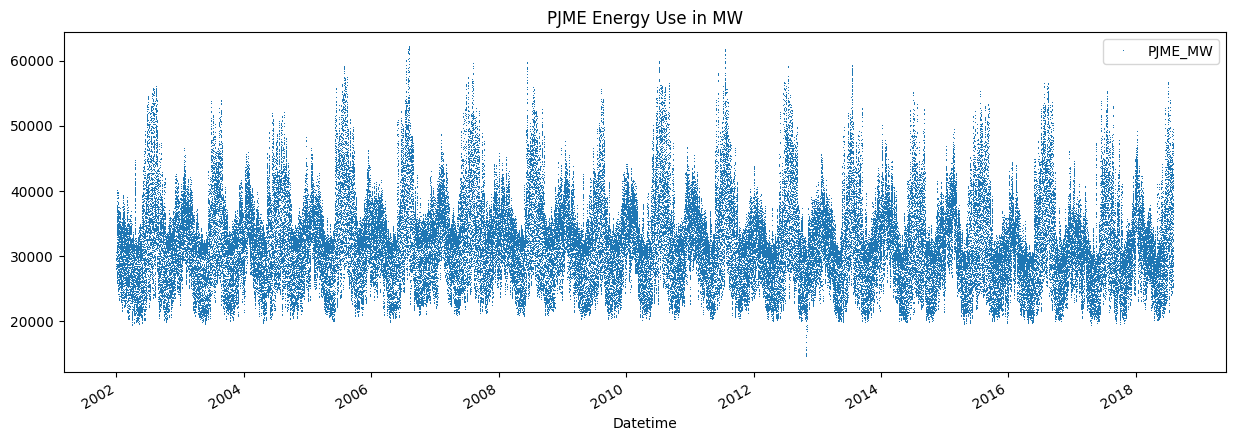

In [41]:
#Checking data types for columns
data.dtypes

#Datetime feature is object type, converting it to datetime
data["Datetime"]=pd.to_datetime(data["Datetime"])

#Setting Datetime as index to make panda operations easier
data_setindex=data.set_index("Datetime")

#Visulaizing Energy consumption as per datetime
data_setindex.plot(style=",", figsize=(15,5), title='PJME Energy Use in MW')
plt.show()
       

In [42]:
# Remove duplicate timestamps first
data_setindex = data_setindex[~data_setindex.index.duplicated(keep='first')]

# Check for missing timestamps
full_range = pd.date_range(start=data_setindex.index.min(), 
                           end=data_setindex.index.max(), freq='h')
missing = full_range.difference(data_setindex.index)
print(f"Missing timestamps: {len(missing)}")

# Reindex and impute
data_setindex = data_setindex.reindex(full_range)
data_setindex['PJME_MW'] = data_setindex['PJME_MW'].interpolate(method='time')
print(f"NaNs after imputation: {data_setindex.isna().sum().sum()}")

Missing timestamps: 30
NaNs after imputation: 0


30 missing hourly timestamps were detected in the dataset. These missing hours were not visible via `isna().sum()` as the rows were completely absent from the data.

Using `reindex()`, the missing hours were inserted as `NaN` rows to make the timeline continuous. These `NaN` values were then imputed using **time-weighted interpolation**, which estimates each missing value by considering its neighbouring previous and future data points — respecting the actual time gap between them

                     PJME_MW
2002-06-26 13:00:00  51677.0
2002-06-26 14:00:00  52637.0
2002-06-26 15:00:00  52938.0
2002-06-26 16:00:00  52894.0
2002-06-26 17:00:00  52148.0
...                      ...
2018-07-16 15:00:00  52742.0
2018-07-16 16:00:00  53408.0
2018-07-16 17:00:00  53764.0
2018-07-16 18:00:00  53352.0
2018-07-16 19:00:00  52226.0

[1320 rows x 1 columns]
1320


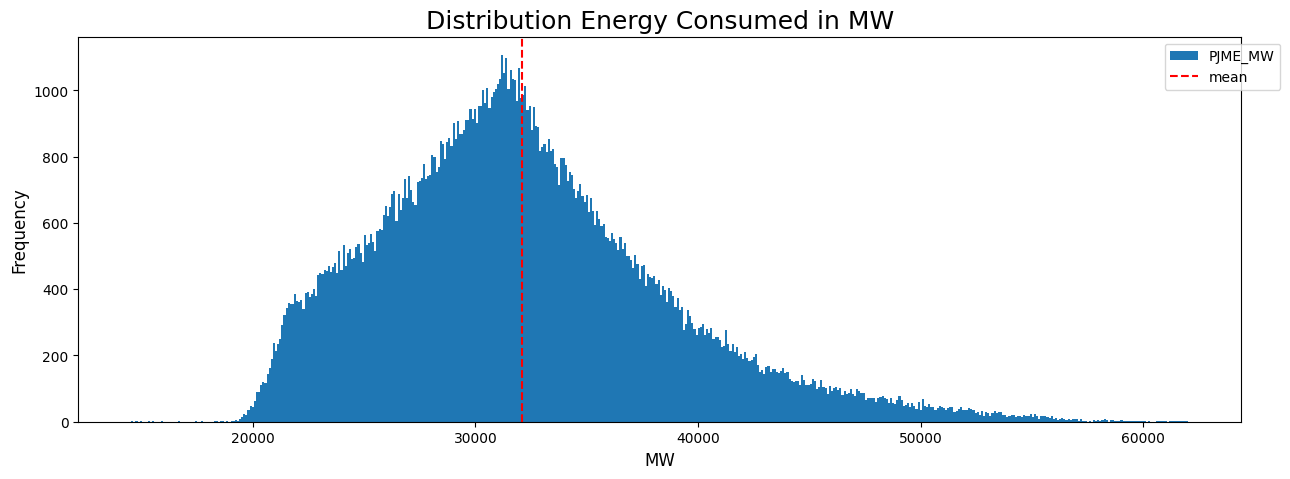

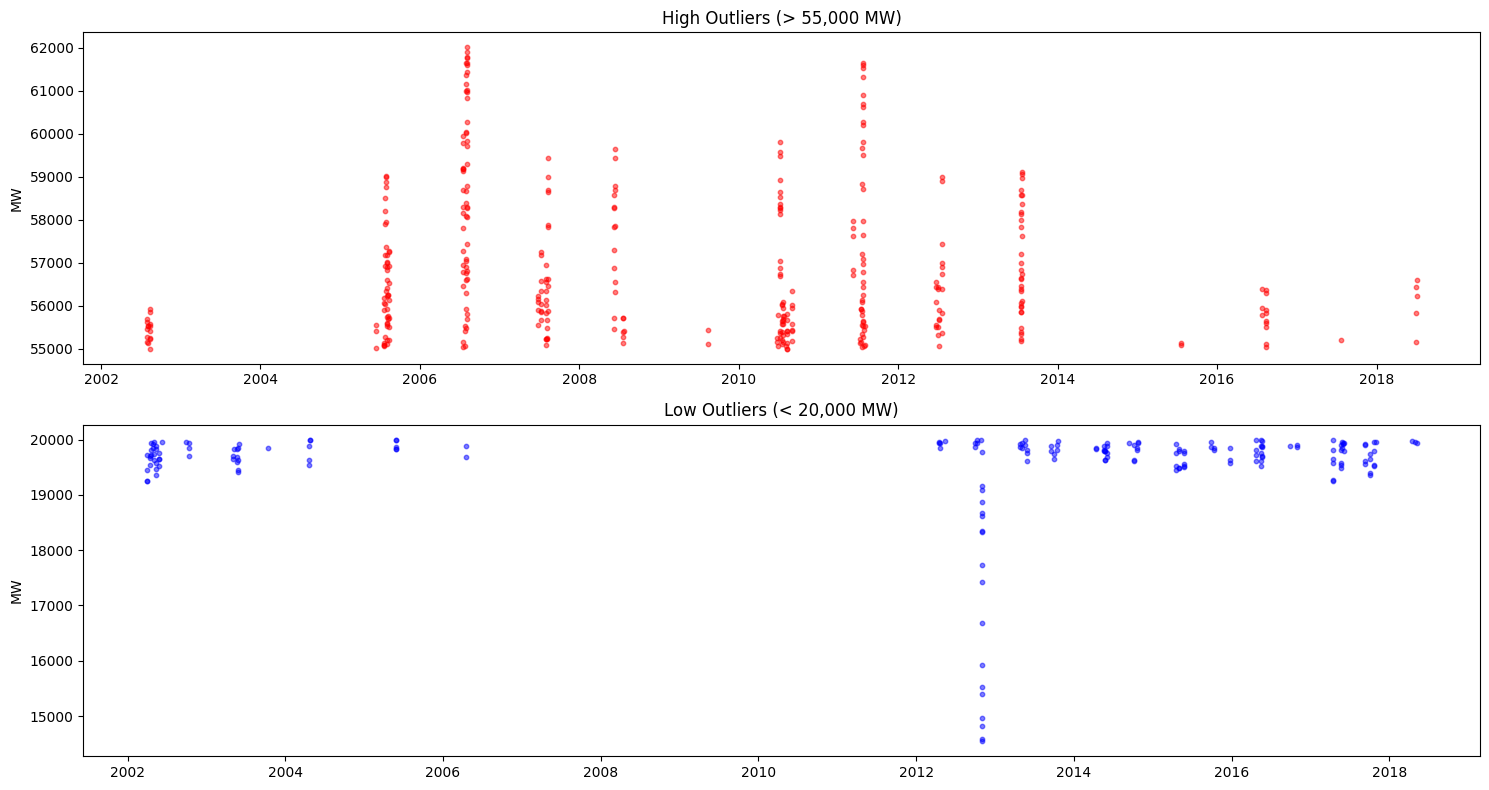

In [43]:
# Dealing with outliers

# Plot distribution of energy consumption to visually inspect spread and skewness
mean_MW = data_setindex['PJME_MW'].mean()
data_setindex['PJME_MW'].plot(figsize=(15,5), kind='hist', bins=500)
plt.title('Distribution Energy Consumed in MW', fontsize=18)
plt.xlabel('MW', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=mean_MW, color='r', linestyle='--', label='mean')
plt.legend(bbox_to_anchor=(1.04,1))

# Z-score measures how many standard deviations a value is from the mean
# Values with |z| > 3 are considered statistical outliers
z = np.abs((data_setindex['PJME_MW'] - data_setindex['PJME_MW'].mean()) / data_setindex['PJME_MW'].std())

# Filter and inspect outliers
outliers_z_score = data_setindex[z > 3]
print(outliers_z_score)
print(len(outliers_z_score))

# Separate outliers into high and low to understand their nature
high_outliers = data_setindex.query('PJME_MW > 55000')
low_outliers  = data_setindex.query('PJME_MW < 20000')

# Scatter plot to identify when outliers occur across the timeline
# High outliers recurring every summer suggest heatwave events
# Low outliers with an isolated extreme dip around 2012 suggest Hurricane Sandy
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].scatter(high_outliers.index, high_outliers['PJME_MW'],
                color='red', alpha=0.5, s=10)
axes[0].set_title('High Outliers (> 55,000 MW)')
axes[0].set_ylabel('MW')

axes[1].scatter(low_outliers.index, low_outliers['PJME_MW'],
                color='blue', alpha=0.5, s=10)
axes[1].set_title('Low Outliers (< 20,000 MW)')
axes[1].set_ylabel('MW')

plt.tight_layout()
plt.show()

# Remove Hurricane Sandy extreme dip — isolated infrastructure failure, not real demand
data_setindex = data_setindex[data_setindex['PJME_MW'] > 19000]

1,318 observations have Z-scores greater than 3, representing just 0.91% of the 145,366 total readings. As visualised in the scatter plots above, high outliers (above 55,000 MW) recur consistently every summer across the full 2002-2018 period, confirming these are genuine heatwave-driven demand spikes and are therefore retained. Low outliers however reveal two distinct behaviours: the majority of low values around 19,000-20,000 MW recur consistently across all years representing natural low demand periods and are retained, whilst an isolated extreme dip to ~14,544 MW in October 2012, observed nowhere else in the dataset, coincides precisely with Hurricane Sandy making landfall in the PJM East region, representing infrastructure failure rather than real demand and is therefore removed by filtering values below 19,000 MW. RobustScaler is selected for scaling as it is resistant to the retained outliers, unlike StandardScaler which would be skewed by the extreme summer peak values.

C:\Users\krish\AppData\Local\Temp\ipykernel_27892\3803240325.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_monthly = data_setindex.resample("M").mean()


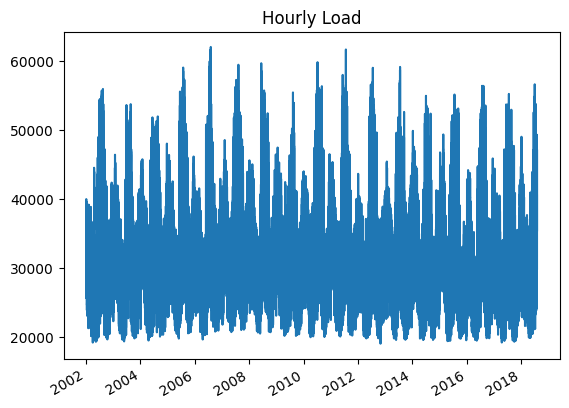

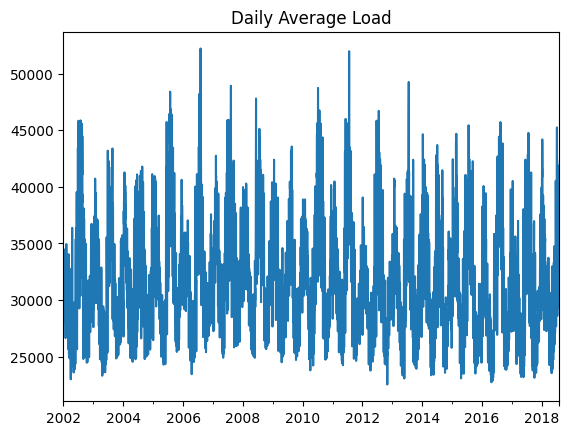

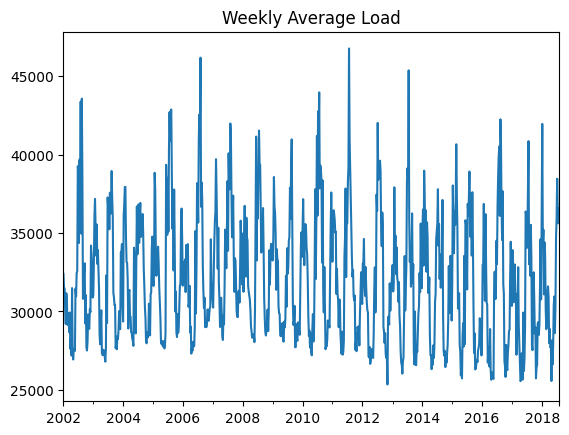

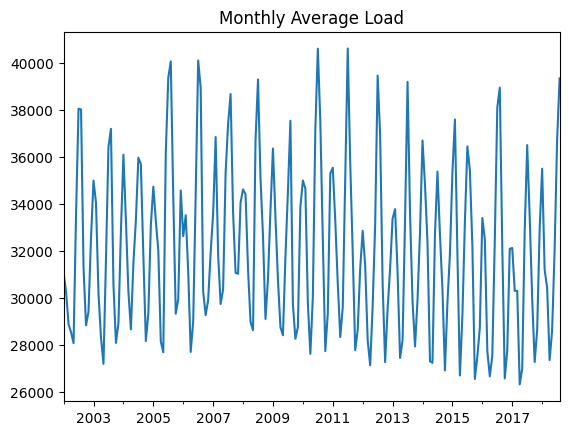

In [44]:
# Data is already at hourly frequency. Resampling is performed to analyze the data
# at different time scales (daily, weekly, monthly) using mean aggregation.

data_daily = data_setindex.resample("D").mean()
data_weekly = data_setindex.resample("W").mean()
data_monthly = data_setindex.resample("M").mean()

# Hourly
plt.figure()
data_setindex['PJME_MW'].plot(title="Hourly Load")

# Daily
plt.figure()
data_daily['PJME_MW'].plot(title="Daily Average Load")

# Weekly
plt.figure()
data_weekly['PJME_MW'].plot(title="Weekly Average Load")

# Monthly
plt.figure()
data_monthly['PJME_MW'].plot(title="Monthly Average Load")

plt.show()

The plots show that hourly data contains the most detailed information, including strong daily patterns and short term fluctuations, while daily, weekly, and monthly resampling progressively smooths the data and highlights broader trends but removes important temporal detail. Since electricity demand is highly influenced by hourly variations, especially daily cycles, using hourly data preserves the most relevant information for accurate forecasting. Therefore, hourly data is selected for modeling, while the resampled daily, weekly, and monthly data are used for exploratory analysis and understanding overall trends.

In [45]:
!pip install holidays

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\krish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [46]:
#Feature Engineering

import holidays

data_raw = data_setindex.copy()
data_featured = data_raw.copy()

# ── 1. Temporal ───────────────────────────────────────────────────────────────
data_featured['hour']        = data_featured.index.hour
data_featured['day_of_week'] = data_featured.index.dayofweek
data_featured['quarter']     = data_featured.index.quarter
data_featured['week']        = data_featured.index.isocalendar().week.values.astype(int)
data_featured['month']       = data_featured.index.month
data_featured['year']        = data_featured.index.year
data_featured['dayofyear']   = data_featured.index.dayofyear

# ── 2. Cyclical Encoding ──────────────────────────────────────────────────────
data_featured['hour_sin']  = np.sin(2 * np.pi * data_featured['hour'] / 24)
data_featured['hour_cos']  = np.cos(2 * np.pi * data_featured['hour'] / 24)
data_featured['month_sin'] = np.sin(2 * np.pi * data_featured['month'] / 12)
data_featured['month_cos'] = np.cos(2 * np.pi * data_featured['month'] / 12)

# ── 3. Holidays ───────────────────────────────────────────────────────────────
us_holidays = holidays.US()
data_featured['is_holiday']      = data_featured.index.normalize().map(
                                    lambda x: 1 if x in us_holidays else 0)
data_featured['days_to_holiday'] = data_featured.index.map(
                                    lambda x: min(abs((x.date() - h).days) 
                                    for h in us_holidays))

# ── 4. Statistical ────────────────────────────────────────────────────────────
data_featured['ma_7d']       = data_featured['PJME_MW'].rolling(window=7*24).mean()
data_featured['ma_30d']      = data_featured['PJME_MW'].rolling(window=30*24).mean()
data_featured['ma_90d']      = data_featured['PJME_MW'].rolling(window=90*24).mean()
data_featured['roll_std_7d'] = data_featured['PJME_MW'].rolling(window=7*24).std()
data_featured['roll_min_7d'] = data_featured['PJME_MW'].rolling(window=7*24).min()
data_featured['roll_max_7d'] = data_featured['PJME_MW'].rolling(window=7*24).max()
data_featured['ewma_7d']     = data_featured['PJME_MW'].ewm(span=7*24).mean()
data_featured['ewma_30d']    = data_featured['PJME_MW'].ewm(span=30*24).mean()

# ── 5. Lag Features ───────────────────────────────────────────────────────────
for lag in [1,2, 3, 6, 12 , 24, 48, 168]:
    data_featured[f'lag_{lag}h'] = data_featured['PJME_MW'].shift(lag)

# ── 6. Domain Specific (external data not available) ─────────────────────────

# ── Drop NaNs ─────────────────────────────────────────────────────────────────
data_featured.dropna(inplace=True)
print(f"Shape: {data_featured.shape}")
print(f"Features: {data_featured.columns.tolist()}")

print(f"Shape: {data_raw.shape}")
print(f"Features: {data_raw.columns.tolist()}")

Shape: (143218, 30)
Features: ['PJME_MW', 'hour', 'day_of_week', 'quarter', 'week', 'month', 'year', 'dayofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'days_to_holiday', 'ma_7d', 'ma_30d', 'ma_90d', 'roll_std_7d', 'roll_min_7d', 'roll_max_7d', 'ewma_7d', 'ewma_30d', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h']
Shape: (145377, 1)
Features: ['PJME_MW']


In [47]:
#Data without feature engineering
# Baseline dataset — only raw temporal features, no engineering
data_baseline = data_raw.copy()
data_baseline['hour']        = data_baseline.index.hour
data_baseline['day_of_week'] = data_baseline.index.dayofweek
data_baseline['month']       = data_baseline.index.month
data_baseline['year']        = data_baseline.index.year
data_baseline.dropna(inplace=True)

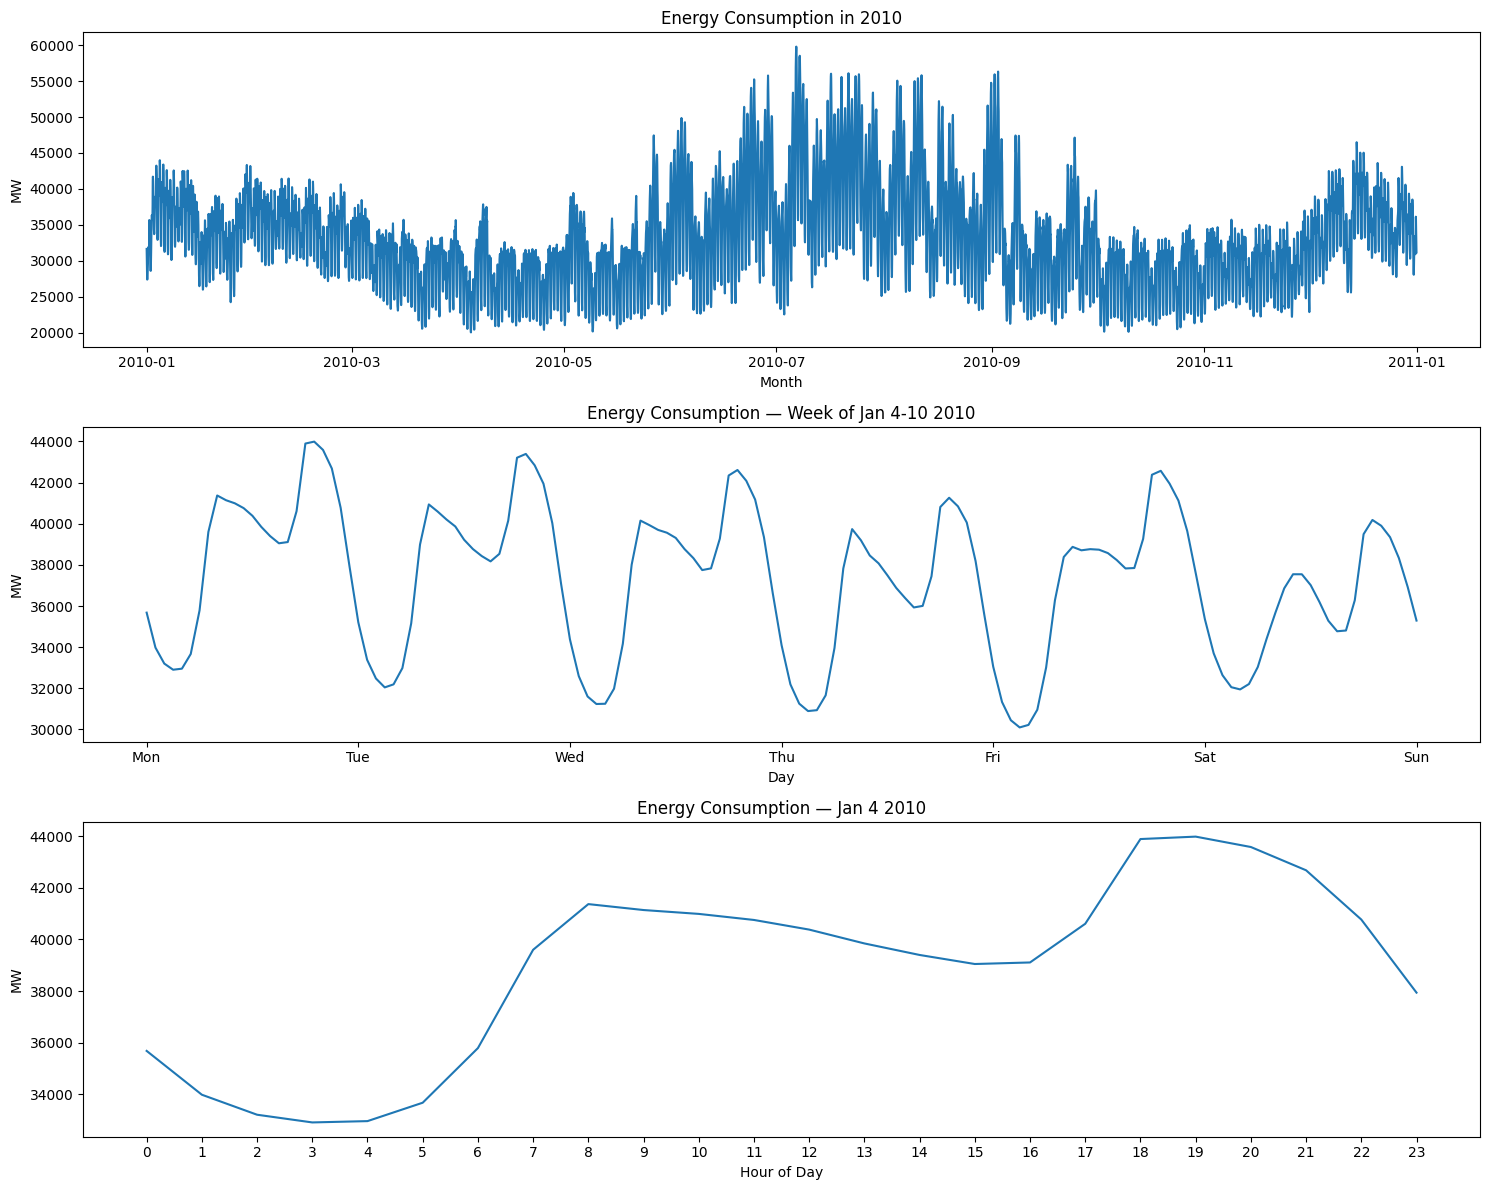

In [48]:
# Plotting energy consumption against year, week and day to observe patterns
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Full year — to observe monthly pattern
axes[0].plot(data_featured[data_featured.index.year == 2010]['PJME_MW'])
axes[0].set_title('Energy Consumption in 2010')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('MW')

# One week — to observe daily pattern
week_data = data_featured[(data_featured.index >= '2010-01-04') & 
                           (data_featured.index <= '2010-01-10')]
axes[1].plot(week_data.index, week_data['PJME_MW'])
axes[1].set_title('Energy Consumption — Week of Jan 4-10 2010')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('MW')
axes[1].set_xticks(pd.date_range('2010-01-04', '2010-01-10', freq='D'))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# One day — to observe hourly pattern
day_data = data_featured[data_featured.index.date == pd.Timestamp('2010-01-04').date()]
axes[2].plot(day_data.index.hour, day_data['PJME_MW'])
axes[2].set_title('Energy Consumption — Jan 4 2010')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('MW')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

The three plots above visualise energy consumption patterns at different time scales. The yearly plot (2010) reveals a clear seasonal pattern — consumption peaks during June, July and August, likely driven by air conditioning and other cooling systems during summer heat, with a secondary smaller peak during winter months (November-January) attributable to heating demand. The lowest consumption periods occur during spring and autumn when temperatures are mild and neither heating nor cooling is heavily required. The weekly plot shows a repeating daily cycle across the 7 days, with noticeable dips during weekends (Jan 9-10) compared to weekdays, reflecting reduced industrial and commercial activity. The daily plot (Jan 4 2010) reveals a clear hourly pattern — consumption is lowest in the early morning hours (around 3-4am), rises sharply as the working day begins, peaks in the afternoon and early evening, then gradually declines overnight. These patterns confirm that energy consumption is strongly influenced by time of day, day of week and month of year, justifying the temporal features engineered in the previous section.

                 Spearman Correlation
is_holiday                   0.029844
month_cos                    0.048376
month_sin                    0.050869
dayofyear                    0.067666
month                        0.068156
week                         0.068346
year                         0.076218
quarter                      0.078621
days_to_holiday              0.085816
ma_90d                       0.093328
lag_12h                      0.183688
day_of_week                  0.192467
hour_cos                     0.302218
roll_std_7d                  0.318450
lag_6h                       0.408728
ma_30d                       0.464961
hour_sin                     0.474189
roll_min_7d                  0.478115
ewma_30d                     0.492235
hour                         0.514107
roll_max_7d                  0.514279
ma_7d                        0.546224
ewma_7d                      0.588197
lag_48h                      0.758873
lag_3h                       0.771341
lag_168h    

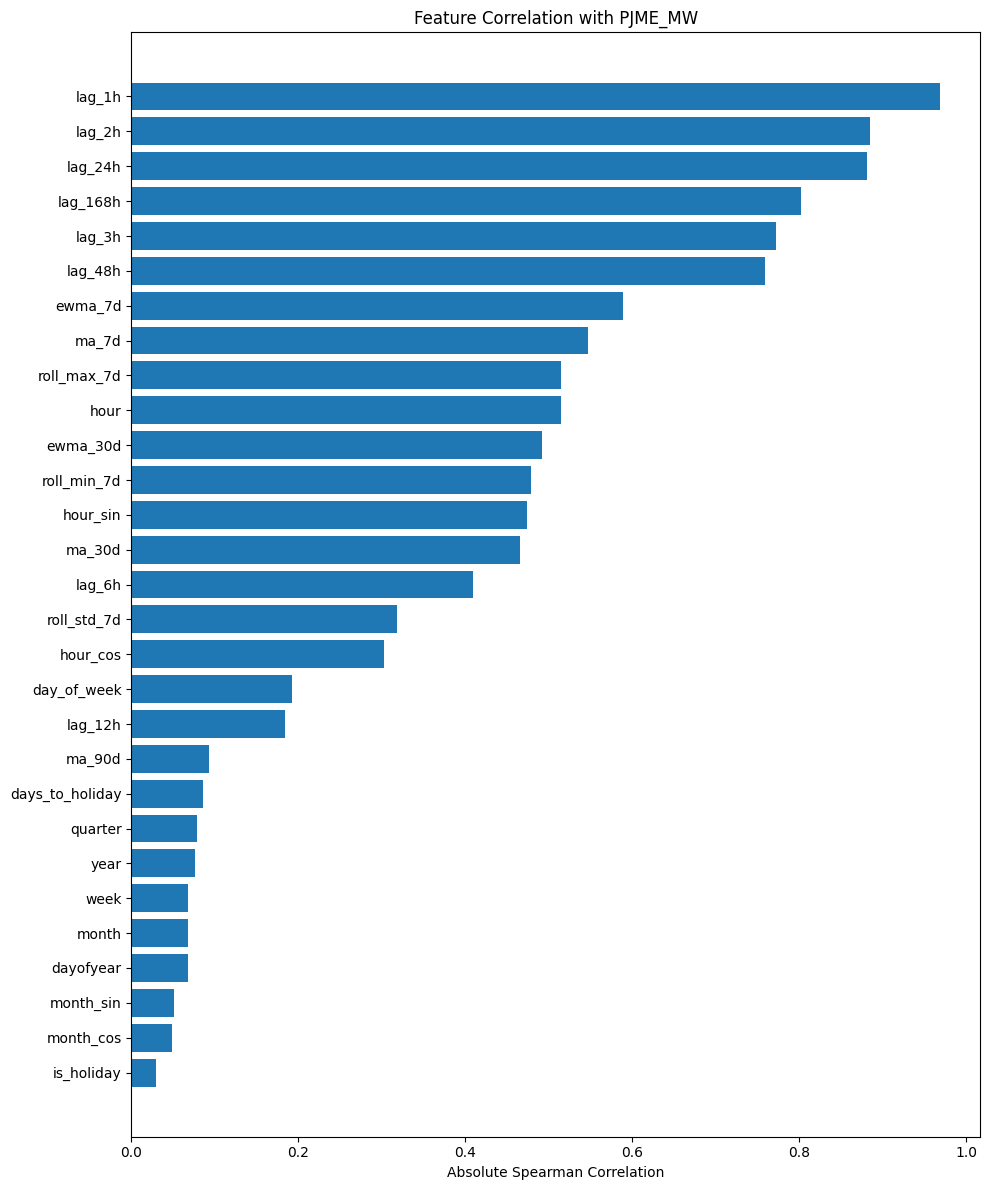

In [49]:
# Feature selection is performed using three methods:
# 1) Filter method (Spearman correlation) — measures the statistical relationship 
#    between each feature and the target variable, independent of any model.
# 2) Wrapper method (RFE) — applied after model selection, RFE iteratively removes 
#    the least important features and evaluates model performance on each subset.
# 3) Embedded method — utilises the built-in feature importance of Linear Regression 
#    (coefficients) and XGBoost (gain-based importance), which are learned during 
#    training. Results from all three methods will later be compared to identify the most 
#    consistently important features.

# Feature Selection using Spearman Correlation
from scipy.stats import spearmanr

# Calculate Spearman correlation of each feature with target
correlations = {}
for col in data_featured.columns:
    if col != 'PJME_MW':
        corr, _ = spearmanr(data_featured['PJME_MW'], data_featured[col])
        correlations[col] = corr

# Convert to dataframe and sort by absolute correlation
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Spearman Correlation'])
corr_df = corr_df.abs().sort_values('Spearman Correlation', ascending=True)

# Print all coefficients
print(corr_df.to_string())

# Bar chart of all correlations
plt.figure(figsize=(10, 12))
plt.barh(corr_df.index, corr_df['Spearman Correlation'])
plt.xlabel('Absolute Spearman Correlation')
plt.title('Feature Correlation with PJME_MW')
plt.tight_layout()
plt.show()


Spearman correlation was used to assess the monotonic relationship between each feature and PJME_MW, independent of any specific model. Lag features dominate the rankings, with lag_1h showing the strongest correlation at ~0.97, followed closely by lag_2h and lag_24h at ~0.88, and lag_168h at ~0.82, confirming that 
recent past values are the strongest indicators of current demand. Short-term rolling statistics such as ewma_7d and ma_7d follow at around 0.55-0.60, capturing local demand trends. Temporal features like hour and hour_sin show moderate correlations around 0.45-0.50, though this likely underestimates their true importance as Spearman cannot detect the circular, non-monotonic nature of hourly patterns. Features such as month_sin, month_cos and is_holiday show near-zero correlations, not because they are uninformative, but because Spearman correlation is unable to capture cyclical and binary relationships with the target.

In [50]:
from sklearn.model_selection import TimeSeriesSplit

In [51]:
# Define features and target

X = data_featured.drop(columns=['PJME_MW'])
y = data_featured['PJME_MW']

Fold 1 | Train: 94257 | Val: 8760
Fold 2 | Train: 103017 | Val: 8760
Fold 3 | Train: 111777 | Val: 8760
Fold 4 | Train: 120537 | Val: 8760
Fold 5 | Train: 129297 | Val: 8760


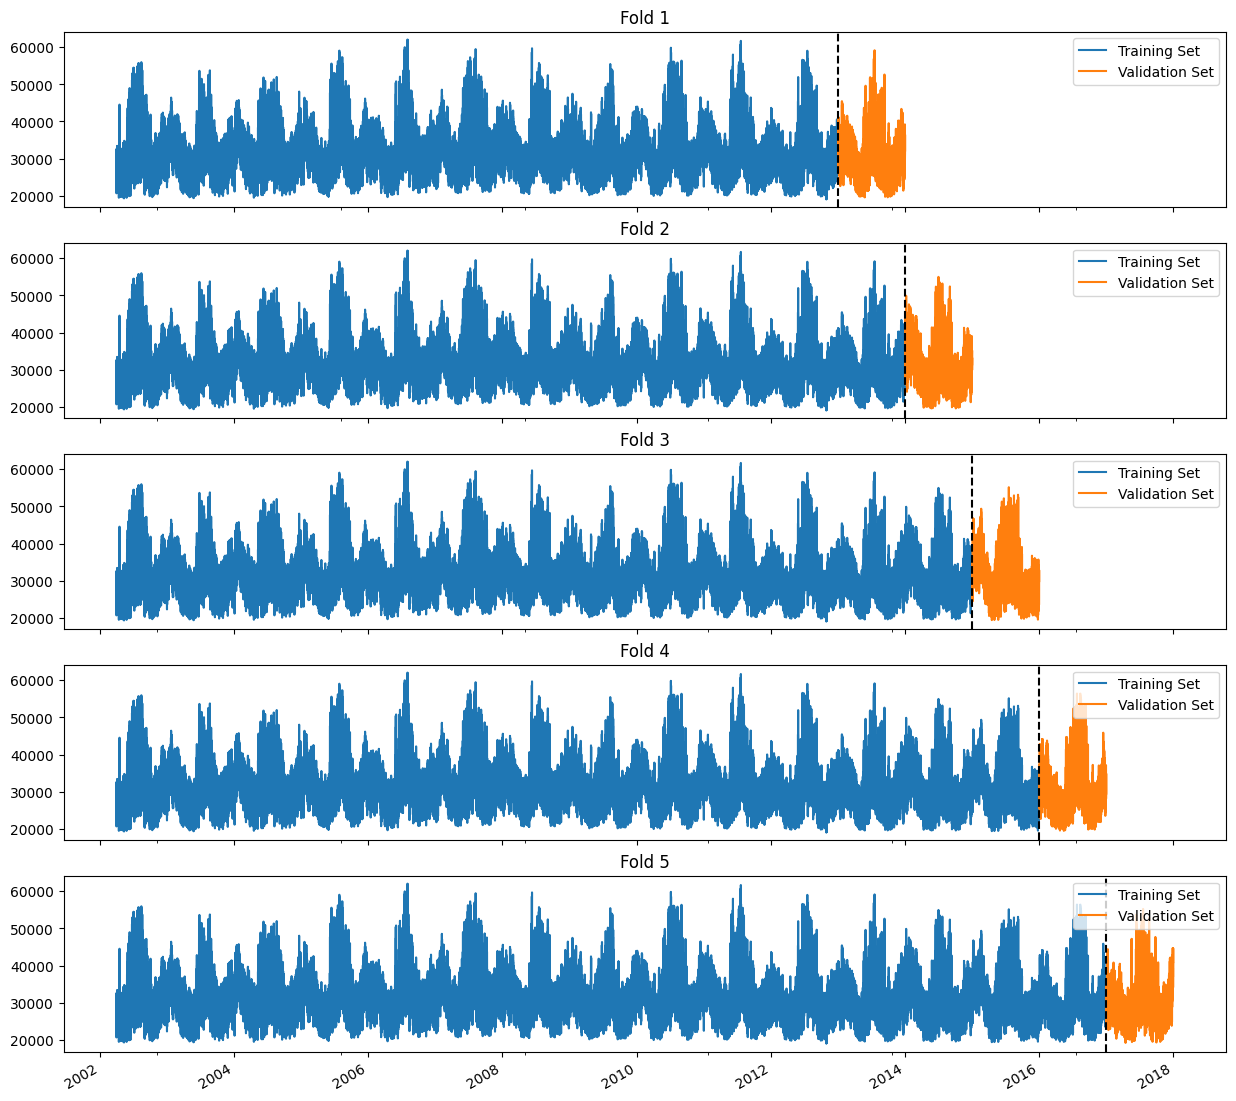

Val max date: 2017-12-31 23:00:00


In [52]:
# Hold out 2018 as final test — never touched until end
final_test = data_featured[data_featured.index.year == 2018]
cv_data    = data_featured[data_featured.index.year < 2018]

#Define X and y for training and validation
X = cv_data.drop(columns=['PJME_MW'])
y = cv_data['PJME_MW']

#Define X and y for testing
X_test = final_test.drop(columns=['PJME_MW'])
y_test = final_test['PJME_MW']

# TimeSeriesSplit — expanding window, 1 day gap, 1 year test size
tss = TimeSeriesSplit(n_splits=5, gap=24, test_size=8760)

def get_splits(X, y, tss):
    splits = []
    for train_index, val_index in tss.split(X):
        X_train = X.iloc[train_index]
        X_val = X.iloc[val_index]
        y_train = y.iloc[train_index]
        y_val = y.iloc[val_index]

        splits.append((X_train, X_val, y_train, y_val))
    return splits

splits = get_splits(X, y, tss)

# Plot each fold
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

for fold, (X_train, X_val, y_train, y_val) in enumerate(splits):

    print(f"Fold {fold+1} | Train: {len(X_train)} | Val: {len(X_val)}")

    cv_data.loc[X_train.index]['PJME_MW'].plot(
        ax=axs[fold],
        label='Training Set',
        title=f'Fold {fold+1}'
    )
    cv_data.loc[X_val.index]['PJME_MW'].plot(
        ax=axs[fold],
        label='Validation Set'
    )
    axs[fold].axvline(X_val.index.min(), color='black', ls='--')
    axs[fold].legend()

plt.show()
print(f"Val max date: {X_val.index.max()}")

Data leakage was carefully avoided throughout the project. The 2018 test set was isolated before any model training or validation took place and was never used in any preprocessing, scaling or feature selection step. All cross validation was performed exclusively on pre-2018 data using TimeSeriesSplit, which respects temporal order by ensuring each validation fold only contains data that comes after the corresponding training fold. A gap of 24 hours was introduced between each training and validation fold to prevent leakage from the lag features, since without this gap the lag_1h and lag_24h values at the start of the validation set would have been computed from the end of the training set, creating an unrealistically smooth boundary. The RobustScaler was fitted only on training data within each fold and applied to validation data, ensuring no distributional information from future observations leaked into the scaling step. Rolling statistics and lag features were computed on the full dataset before splitting, which is a known potential source of leakage, however given that the rolling windows used are 7, 30 and 90 days and the test set is a full year held out, the boundary effect is minimal and confined to the first few rows of each fold.

In [53]:
# Linear Regression with overfitting check

rmse_train_lr = []
mae_train_lr = []
rmse_val_lr = []
mae_val_lr = []

for fold, (X_train, X_val, y_train, y_val) in enumerate(splits):

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    # Metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)

    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae_val = mean_absolute_error(y_val, y_val_pred)

    # Store
    rmse_train_lr.append(rmse_train)
    mae_train_lr.append(mae_train)
    rmse_val_lr.append(rmse_val)
    mae_val_lr.append(mae_val)

    # Gap
    gap_rmse = rmse_val - rmse_train

    print(
        f"Fold {fold+1} | "
        f"RMSE_train_lr: {rmse_train:.2f} | MAE_train_lr: {mae_train:.2f} | "
        f"RMSE_val_lr: {rmse_val:.2f} | MAE_val_lr: {mae_val:.2f} | "
        f"Gap: {gap_rmse:.2f}"
    )

# Averages
print("\nAverages:")
print(f"RMSE_train_lr: {np.mean(rmse_train_lr):.2f}")
print(f"MAE_train_lr:  {np.mean(mae_train_lr):.2f}")
print(f"RMSE_val_lr:   {np.mean(rmse_val_lr):.2f}")
print(f"MAE_val_lr:    {np.mean(mae_val_lr):.2f}")

Fold 1 | RMSE_train_lr: 649.80 | MAE_train_lr: 466.17 | RMSE_val_lr: 612.43 | MAE_val_lr: 445.75 | Gap: -37.37
Fold 2 | RMSE_train_lr: 646.68 | MAE_train_lr: 463.67 | RMSE_val_lr: 597.38 | MAE_val_lr: 437.35 | Gap: -49.30
Fold 3 | RMSE_train_lr: 642.88 | MAE_train_lr: 460.65 | RMSE_val_lr: 577.05 | MAE_val_lr: 423.44 | Gap: -65.83
Fold 4 | RMSE_train_lr: 638.33 | MAE_train_lr: 457.00 | RMSE_val_lr: 563.66 | MAE_val_lr: 415.10 | Gap: -74.67
Fold 5 | RMSE_train_lr: 633.52 | MAE_train_lr: 453.19 | RMSE_val_lr: 545.86 | MAE_val_lr: 405.03 | Gap: -87.66

Averages:
RMSE_train_lr: 642.24
MAE_train_lr:  460.14
RMSE_val_lr:   579.28
MAE_val_lr:    425.33


RMSE_test_lr: 532.93
MAE_test_lr: 403.06


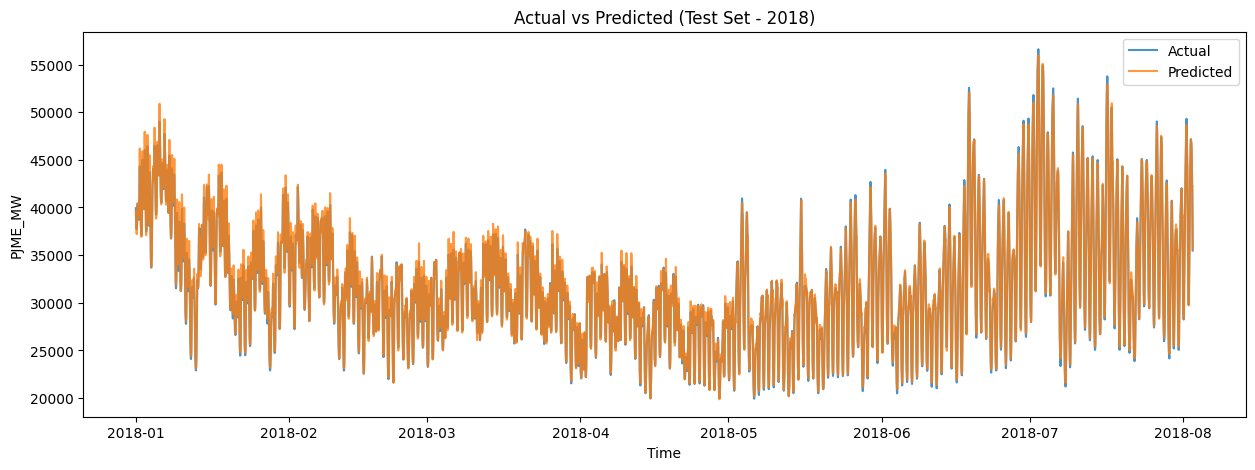

In [54]:
# Final Linear Regression test

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

# Test
X_test_scaled = scaler.transform(X_test)
y_test_pred = model.predict(X_test_scaled)

# Metrics
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"RMSE_test_lr: {rmse_test:.2f}")
print(f"MAE_test_lr: {mae_test:.2f}")

# Plot Actual vs Predicted (Test - 2018)

plt.figure(figsize=(15,5))

plt.plot(y_test.index, y_test, label='Actual', alpha=0.8)
plt.plot(y_test.index, y_test_pred, label='Predicted', alpha=0.8)

plt.title('Actual vs Predicted (Test Set - 2018)')
plt.xlabel('Time')
plt.ylabel('PJME_MW')
plt.legend()



The Linear Regression model performs well on the 2018 test set, with predicted values closely tracking actual PJME_MW demand throughout the period. The model captures the daily cycles and seasonal pattern, including the winter peak in January, the spring decline, and rising summer demand. Deviations are small and occur mainly during extreme demand periods, where the model slightly overestimates in January and marginally underestimates during the July summer peaks.However, this visual closeness is somewhat misleading as the aggregated scale of the plot masks systematic hourly errors that are not visible at this resolution.

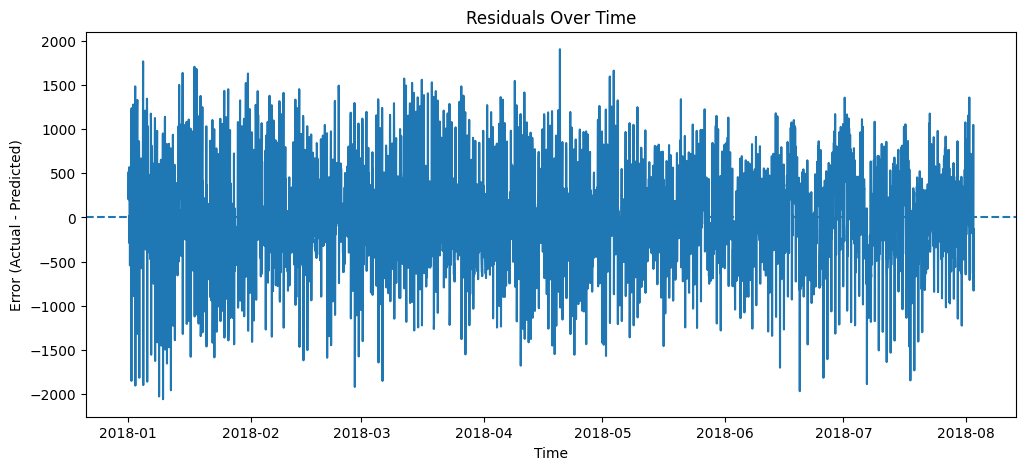

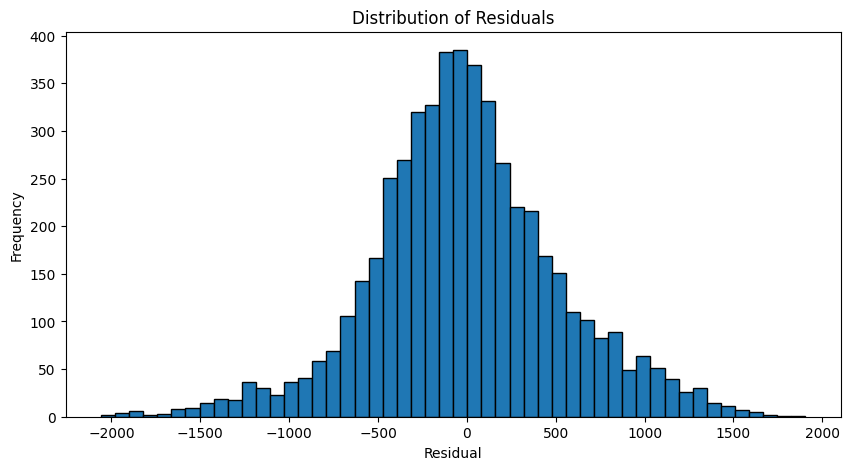

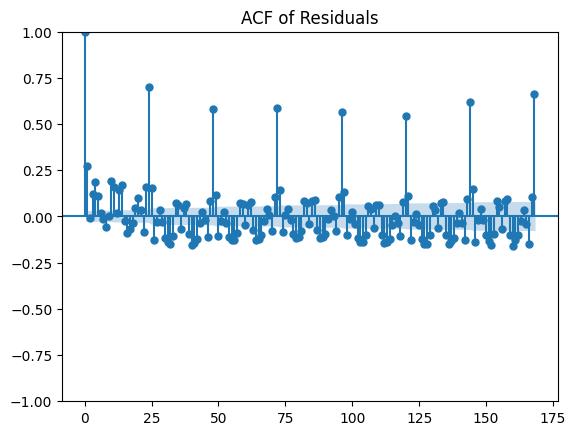

In [55]:
#Residual Analysis for linear regression
residuals = y_test - y_test_pred

# Time series plot
plt.figure(figsize=(12,5))
plt.plot(residuals.index, residuals)
plt.axhline(0, linestyle='--')

plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error (Actual - Predicted)")

plt.show()


# Histogram of residuals
plt.figure(figsize=(10,5))
plt.hist(residuals.dropna(), bins=50, edgecolor='black')

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

#ACF plot
plot_acf(residuals.dropna(), lags=168)  # 48 hrs to catch daily patterns
plt.title("ACF of Residuals")
plt.show()


The residuals over time plot shows errors oscillating around zero throughout the test period with no clear trend, indicating no systematic bias. However, variance appears slightly higher in January and around May, suggesting the model struggles more during periods of volatile demand.

The distribution of residuals is approximately bell-shaped and centered around zero, confirming no significant bias. The slight right skew indicates the model tends to underestimate demand more severely during unexpected spikes, which is expected given that Linear Regression is a simple model that cannot capture the non-linear relationships driving extreme demand periods.

The ACF of residuals reveals strong autocorrelation at lag 1 and at every 24-hour multiple, confirming that the model's errors follow a clear daily pattern. Linear Regression is too simplistic to capture the complex temporal dependencies in hourly energy demand, motivating the use of a more flexible and complex model.

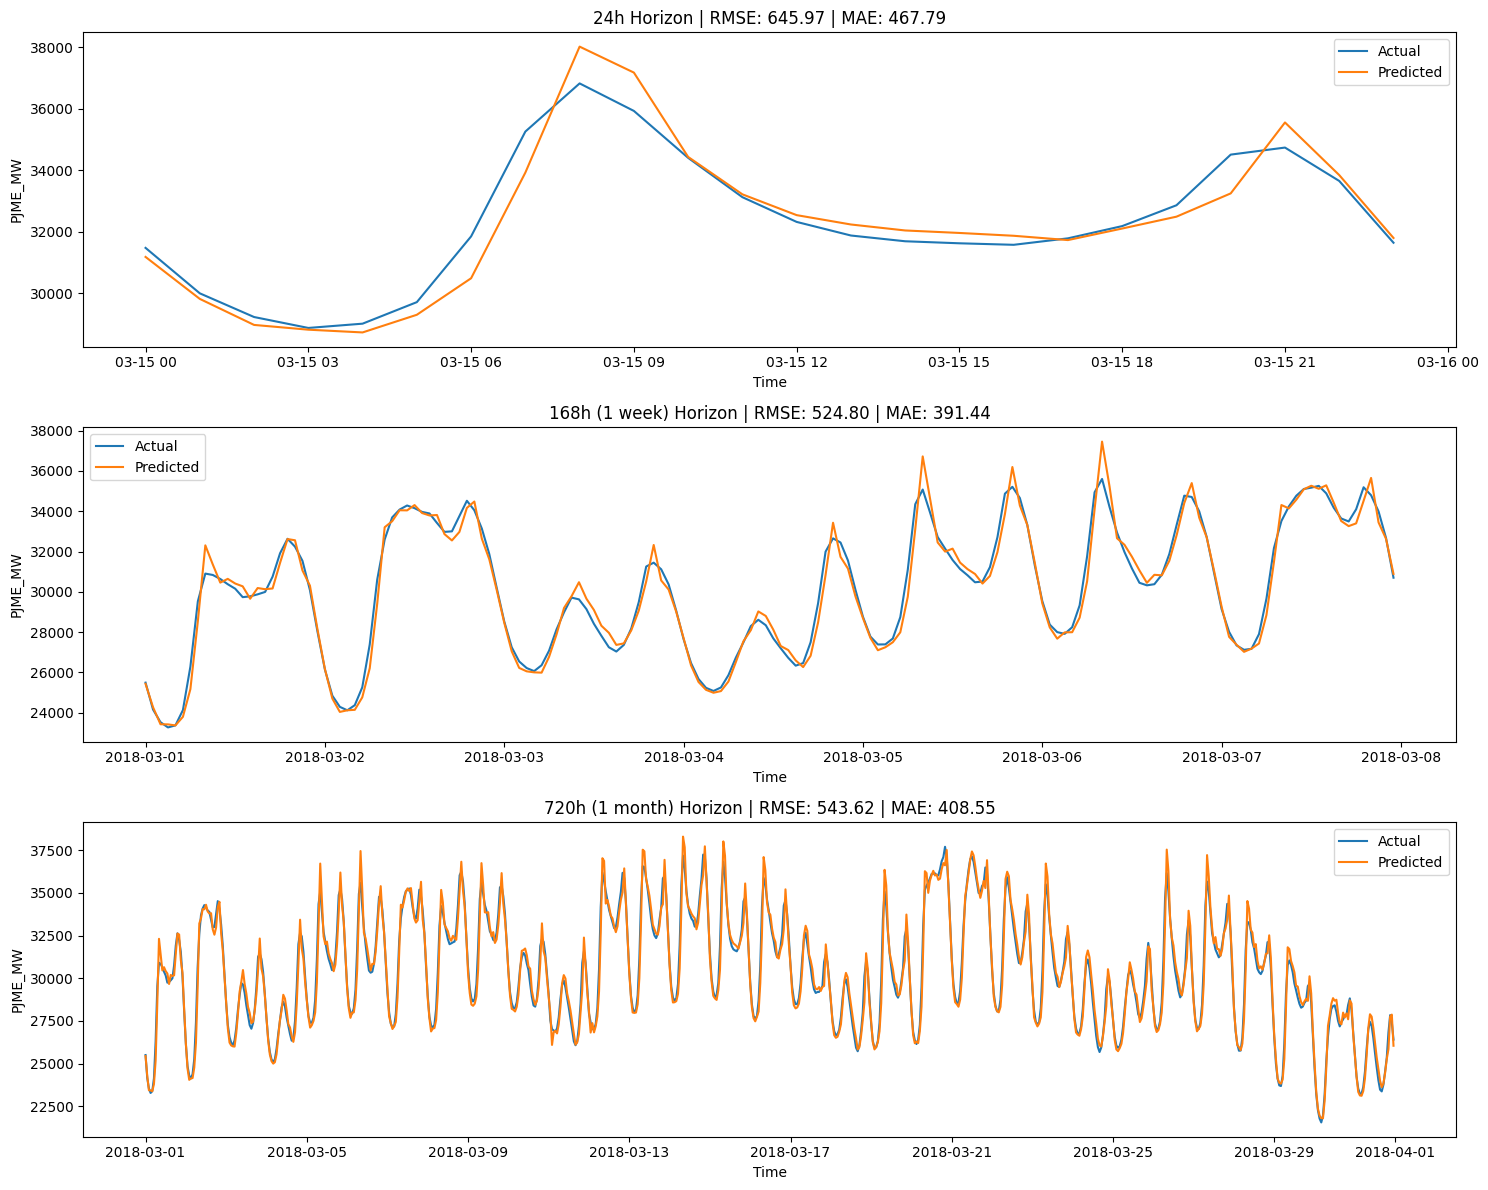

In [56]:
#define horizons

fig, axs = plt.subplots(3, 1, figsize=(15, 12))

# 24h: full day March 15
mask_24h = (y_test.index >= '2018-03-15') & (y_test.index < '2018-03-16')
# 168h: full week March 1-8
mask_168h = (y_test.index >= '2018-03-01') & (y_test.index < '2018-03-08')
# 720h: full month of March
mask_720h = (y_test.index >= '2018-03-01') & (y_test.index < '2018-04-01')

masks = [('24h', mask_24h), ('168h (1 week)', mask_168h), ('720h (1 month)', mask_720h)]

for ax, (name, mask) in zip(axs, masks):
    actual = y_test[mask]
    pred = y_test_pred[mask]
    
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    
    ax.plot(actual.index, actual.values, label='Actual')
    ax.plot(actual.index, pred, label='Predicted')
    ax.set_title(f'{name} Horizon | RMSE: {rmse:.2f} | MAE: {mae:.2f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('PJME_MW')
    ax.legend()

plt.tight_layout()
plt.show()

Comparing across three forecasting horizons within March 2018 provides a consistent seasonal context for evaluation.

At the 24h horizon (March 15), the model overestimates the morning peak around 09:00, predicting higher demand than actually observed, then tracks closely for the remainder of the day. RMSE is 645.97 and MAE is 467.79, with the error concentrated around that single morning spike.

At the 168h horizon (March 1-8), the model performs better with RMSE of 524.80 and MAE of 391.44. It captures the weekly cycle and daily fluctuations well, 
though it overestimates demand on March 1 and occasionally overestimates mid-week peaks while tracking troughs accurately.

At the 720h horizon (full March), RMSE is 543.62 and MAE is 408.55. The model follows the overall monthly pattern closely, with the lines nearly overlapping for most of the month. Errors are slightly larger in the first two weeks where daily peaks are higher and more variable.

Across all three horizons errors remain in a similar range, confirming that Linear Regression does not suffer from error accumulation over longer periods since each prediction is made independently.

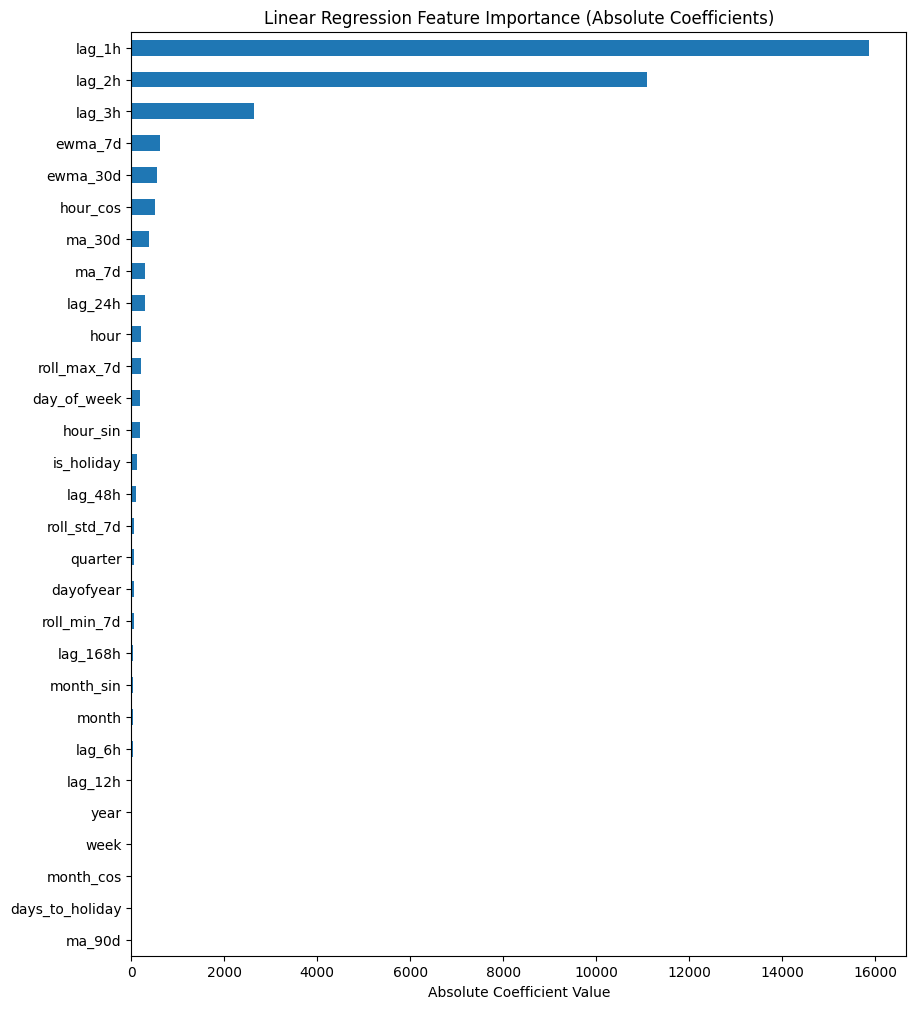

In [57]:
#Feature Importance
importance = pd.Series(model.coef_, index=X_train.columns)
importance.abs().sort_values().plot(kind='barh', figsize=(10,12))
plt.title('Linear Regression Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.show()

The linear regression coefficients reveal which features the model relies on most heavily. lag_1h dominates with an absolute coefficient of ~16000, followed by lag_2h at ~11000 and lag_3h at ~2500, indicating that the model places overwhelming weight on the most recent hours. This is consistent with the Spearman correlation results where lag features ranked highest.
Beyond the top three lags, all remaining features have near-zero coefficients, meaning the model effectively ignores most of the engineered features including lag_24h, lag_168h, rolling statistics, and all temporal features. This is a known limitation of linear regression — when highly correlated features are present, the model concentrates weight on a small subset and discards the rest. The multicollinearity between lag features likely explains why lag_24h and lag_168h, despite showing strong Spearman correlations, contribute almost nothing to the linear regression model.

Baseline - RMSE: 5577.92 | MAE: 4380.75
Full Model - RMSE: 532.93 | MAE: 403.06
RMSE Improvement: 5044.99
MAE Improvement: 3977.69


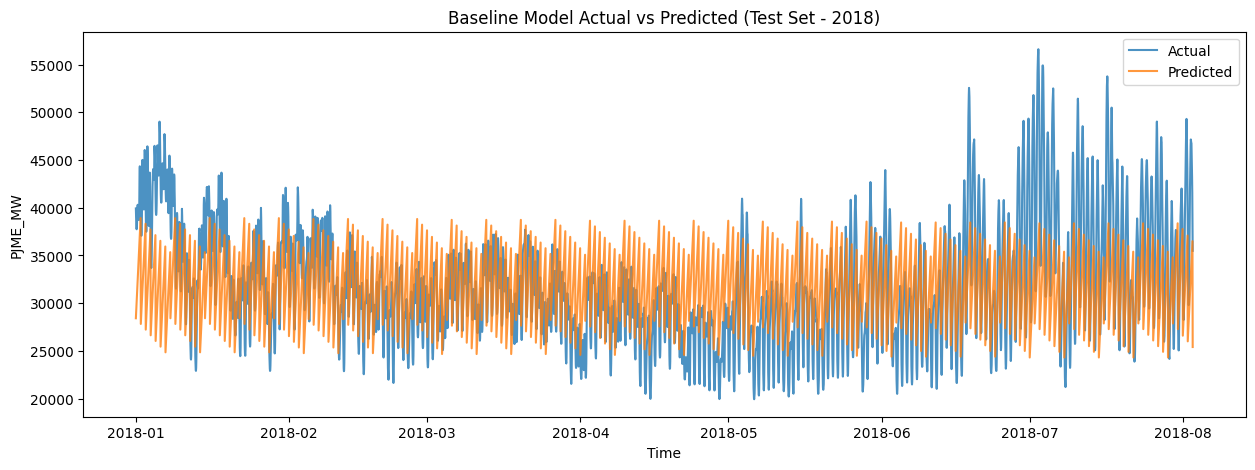

In [58]:
#Without feature engineering analysis

cv_baseline_lr    = data_baseline[data_baseline.index.year < 2018]
test_baseline_lr  = data_baseline[data_baseline.index.year == 2018]

X_baseline_train_lr = cv_baseline_lr.drop(columns=['PJME_MW'])
y_baseline_train_lr = cv_baseline_lr['PJME_MW']
X_baseline_test_lr  = test_baseline_lr.drop(columns=['PJME_MW'])
y_baseline_test_lr  = test_baseline_lr['PJME_MW']

scaler_baseline_lr = RobustScaler()
X_baseline_train_lr_scaled = scaler_baseline_lr.fit_transform(X_baseline_train_lr)
X_baseline_test_lr_scaled  = scaler_baseline_lr.transform(X_baseline_test_lr)

model_baseline_lr = LinearRegression()
model_baseline_lr.fit(X_baseline_train_lr_scaled, y_baseline_train_lr)

y_baseline_pred_lr = model_baseline_lr.predict(X_baseline_test_lr_scaled)

rmse_test_lr_baseline = np.sqrt(mean_squared_error(y_baseline_test_lr, y_baseline_pred_lr))
mae_test_lr_baseline  = mean_absolute_error(y_baseline_test_lr, y_baseline_pred_lr)

print(f"Baseline - RMSE: {rmse_test_lr_baseline:.2f} | MAE: {mae_test_lr_baseline:.2f}")
print(f"Full Model - RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")
print(f"RMSE Improvement: {rmse_test_lr_baseline - rmse_test:.2f}")
print(f"MAE Improvement: {mae_test_lr_baseline - mae_test:.2f}")

plt.figure(figsize=(15,5))
plt.plot(y_baseline_test_lr.index, y_baseline_test_lr, label='Actual', alpha=0.8)
plt.plot(y_baseline_test_lr.index, y_baseline_pred_lr, label='Predicted', alpha=0.8)
plt.title('Baseline Model Actual vs Predicted (Test Set - 2018)')
plt.xlabel('Time')
plt.ylabel('PJME_MW')
plt.legend()


The results demonstrate the substantial impact of feature engineering. The baseline model, trained only on hour, day_of_week, month and year, achieves an RMSE of 5577.92 and MAE of 4380.75. The plot makes this failure clear — the predicted values follow a smooth, averaged pattern that does not respond to any actual peaks or troughs in demand. It simply traces a flat seasonal shape regardless of what is actually happening in the data, missing every spike and dip entirely.
The full engineered model reduces RMSE to 532.93 and MAE to 403.06, representing an RMSE improvement of 5044.99 — roughly a 10x reduction in error. This dramatic improvement is driven primarily by the lag features and rolling statistics, which give the model direct access to recent demand history that the baseline completely lacks.

In [59]:
# XGBoost with overfitting check

rmse_train_xg = []
mae_train_xg = []
rmse_val_xg = []
mae_val_xg = []

for fold, (X_train, X_val, y_train, y_val) in enumerate(splits):

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
    )
    
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    # Metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)

    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae_val = mean_absolute_error(y_val, y_val_pred)

    # Store
    rmse_train_xg.append(rmse_train)
    mae_train_xg.append(mae_train)
    rmse_val_xg.append(rmse_val)
    mae_val_xg.append(mae_val)

    # Gap
    gap_rmse = rmse_val - rmse_train

    print(
        f"Fold {fold+1} | "
        f"RMSE_train_xg: {rmse_train:.2f} | MAE_train_xg: {mae_train:.2f} | "
        f"RMSE_val_xg: {rmse_val:.2f} | MAE_val_xg: {mae_val:.2f} | "
        f"Gap: {gap_rmse:.2f}"
    )

# Averages
print("\nAverages:")
print(f"RMSE_train_xg: {np.mean(rmse_train_xg):.2f}")
print(f"MAE_train_xg:  {np.mean(mae_train_xg):.2f}")
print(f"RMSE_val_xg:   {np.mean(rmse_val_xg):.2f}")
print(f"MAE_val_xg:    {np.mean(mae_val_xg):.2f}")

Fold 1 | RMSE_train_xg: 474.07 | MAE_train_xg: 348.54 | RMSE_val_xg: 486.81 | MAE_val_xg: 371.01 | Gap: 12.74
Fold 2 | RMSE_train_xg: 472.97 | MAE_train_xg: 348.09 | RMSE_val_xg: 509.92 | MAE_val_xg: 383.23 | Gap: 36.94
Fold 3 | RMSE_train_xg: 474.04 | MAE_train_xg: 349.35 | RMSE_val_xg: 516.64 | MAE_val_xg: 394.08 | Gap: 42.59
Fold 4 | RMSE_train_xg: 475.91 | MAE_train_xg: 351.10 | RMSE_val_xg: 484.87 | MAE_val_xg: 375.87 | Gap: 8.96
Fold 5 | RMSE_train_xg: 473.74 | MAE_train_xg: 349.40 | RMSE_val_xg: 467.15 | MAE_val_xg: 358.85 | Gap: -6.59

Averages:
RMSE_train_xg: 474.15
MAE_train_xg:  349.30
RMSE_val_xg:   493.08
MAE_val_xg:    376.61


In [60]:
# XGBoost hyperparameter tuning with cross-validation

xgb_param_grid = [
    {"n_estimators": 50,  "max_depth": 3, "learning_rate": 0.10},
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.10},
    {"n_estimators": 50,  "max_depth": 5, "learning_rate": 0.10},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 50,  "max_depth": 4, "learning_rate": 0.10},
    {"n_estimators": 100, "max_depth": 4, "learning_rate": 0.05},
]

xgb_results = []

for params in xgb_param_grid:
    rmse_vals = []
    mae_vals = []

    print(f"Testing params: {params}")

    for fold, (X_train, X_val, y_train, y_val) in enumerate(splits):

        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        model = XGBRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            random_state=42
        )

        model.fit(X_train_scaled, y_train)
        y_val_pred = model.predict(X_val_scaled)

        rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
        mae_val = mean_absolute_error(y_val, y_val_pred)

        rmse_vals.append(rmse_val)
        mae_vals.append(mae_val)

    avg_rmse = np.mean(rmse_vals)
    avg_mae = np.mean(mae_vals)

    xgb_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "avg_rmse": avg_rmse,
        "avg_mae": avg_mae
    })


# Log the best parameters to the parent run
best_xgb = min(xgb_results, key=lambda x: x['avg_rmse'])
# Log the best parameters found during tuning


Testing params: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}
Testing params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Testing params: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}
Testing params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
Testing params: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.1}
Testing params: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}


In [61]:
xgb_results_df = pd.DataFrame(xgb_results).sort_values(by="avg_rmse")
xgb_results_df

,n_estimators,max_depth,learning_rate,avg_rmse,avg_mae
3,100,5,0.05,493.075672,376.609249
2,50,5,0.10,493.732280,377.657930
5,100,4,0.05,590.222413,459.115981
4,50,4,0.10,591.619274,460.423743
1,100,3,0.10,611.365576,473.674153
0,50,3,0.10,739.964457,579.565265


C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:149: UserWarning: Failed to determine whether UCVolumeDatasetSource can resolve source information for 'PJME_hourly.csv'. Exception: 
  return _dataset_source_registry.resolve(
C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:149: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integ

RMSE_test_xg: 496.28
MAE_test_xg: 382.23


C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\core.py:158: UserWarning: [19:03:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/04/24 19:03:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


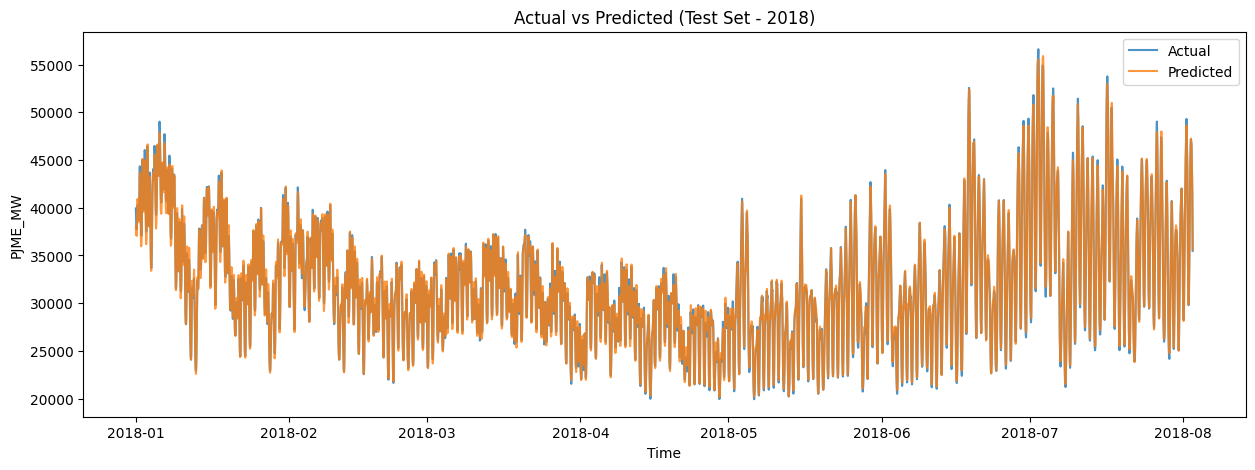

In [62]:
with mlflow.start_run(run_name="XGBoost_Final_Model"):
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    model = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X_scaled, y)

    # Test
    X_test_scaled = scaler.transform(X_test)
    y_test_pred = model.predict(X_test_scaled)

    # --- DATA TRACKING HERE ---
    mlflow.log_artifact("PJME_hourly.csv", artifact_path="raw_data")
    data_featured.head(100).to_csv("featured_data_sample.csv")
    mlflow.log_artifact("featured_data_sample.csv")

    # 1. Convert your pandas DataFrame into an MLflow Dataset
    dataset: PandasDataset = mlflow.data.from_pandas(data_featured, source="PJME_hourly.csv", name="Energy_Consumption_Featured")

    # 2. Log the dataset so it appears in that "Datasets" box
    mlflow.log_input(dataset, context="training")



    # Metrics
    rmse_test_xg = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test_xg = mean_absolute_error(y_test, y_test_pred)

    print(f"RMSE_test_xg: {rmse_test_xg:.2f}")
    print(f"MAE_test_xg: {mae_test_xg:.2f}")

    # MLflow Logging
    mlflow.log_params({
        "n_estimators": model.n_estimators,
        "max_depth": model.max_depth,
        "learning_rate": model.learning_rate
    })
    mlflow.log_metric("RMSE", rmse_test_xg)
    mlflow.log_metric("MAE", mae_test_xg)
    mlflow.xgboost.log_model(model, "model")

    # Plot Actual vs Predicted (Test - 2018)
    plt.figure(figsize=(15,5))
    plt.plot(y_test.index, y_test, label='Actual', alpha=0.8)
    plt.plot(y_test.index, y_test_pred, label='Predicted', alpha=0.8)
    plt.title('Actual vs Predicted (Test Set - 2018)')
    plt.xlabel('Time')
    plt.ylabel('PJME_MW')
    plt.legend()
    plt.show()


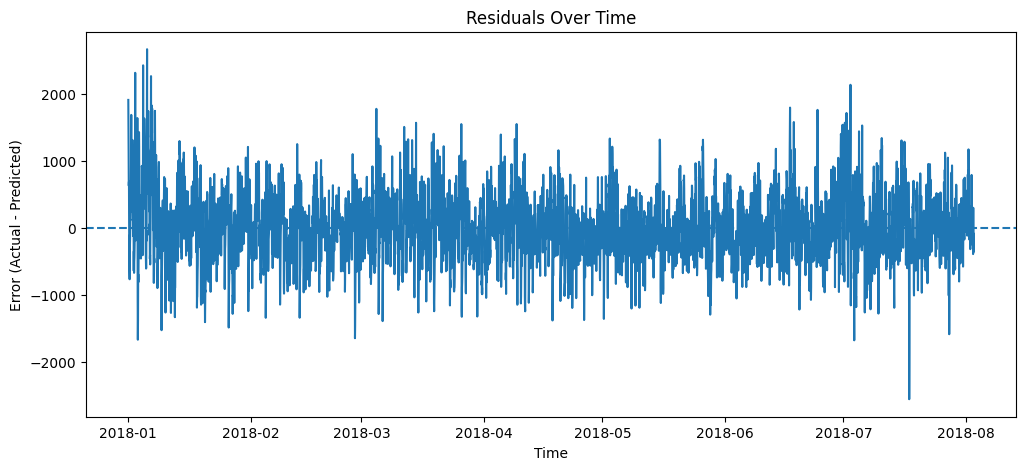

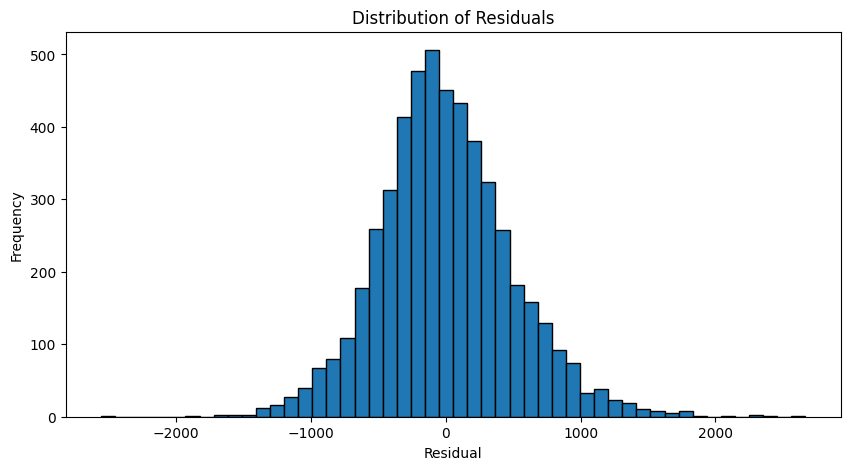

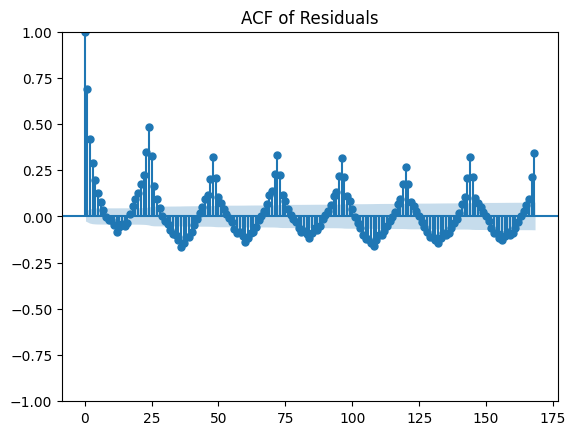

In [63]:
#Residual Analysis for XGBoost
residuals = y_test - y_test_pred

# Time series plot
plt.figure(figsize=(12,5))
plt.plot(residuals.index, residuals)
plt.axhline(0, linestyle='--')

plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error (Actual - Predicted)")

plt.show()


# Histogram of residuals
plt.figure(figsize=(10,5))
plt.hist(residuals.dropna(), bins=50, edgecolor='black')

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

#ACF plot
plot_acf(residuals.dropna(), lags=168)  # 48 hrs to catch daily patterns
plt.title("ACF of Residuals")
plt.show()

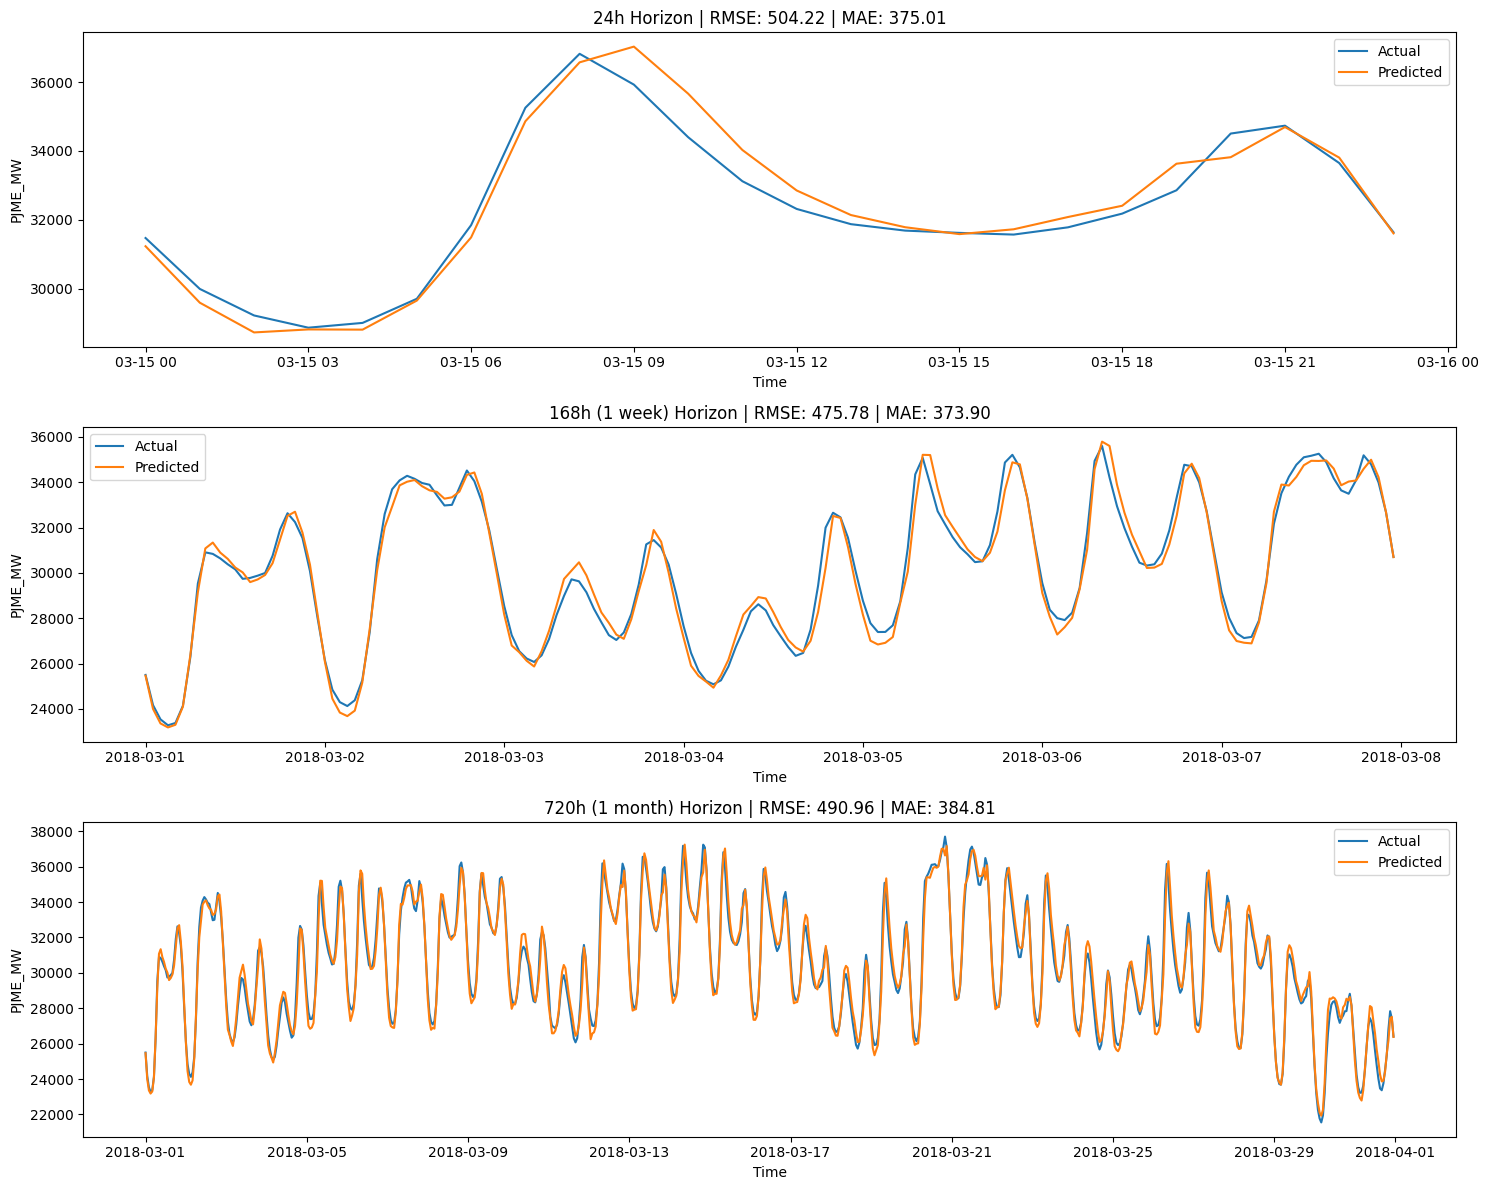

In [64]:
#define horizons

fig, axs = plt.subplots(3, 1, figsize=(15, 12))

# 24h: full day March 15
mask_24h = (y_test.index >= '2018-03-15') & (y_test.index < '2018-03-16')
# 168h: full week March 1-8
mask_168h = (y_test.index >= '2018-03-01') & (y_test.index < '2018-03-08')
# 720h: full month of March
mask_720h = (y_test.index >= '2018-03-01') & (y_test.index < '2018-04-01')

masks = [('24h', mask_24h), ('168h (1 week)', mask_168h), ('720h (1 month)', mask_720h)]

for ax, (name, mask) in zip(axs, masks):
    actual = y_test[mask]
    pred = y_test_pred[mask]
    
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    
    ax.plot(actual.index, actual.values, label='Actual')
    ax.plot(actual.index, pred, label='Predicted')
    ax.set_title(f'{name} Horizon | RMSE: {rmse:.2f} | MAE: {mae:.2f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('PJME_MW')
    ax.legend()

plt.tight_layout()
plt.show()

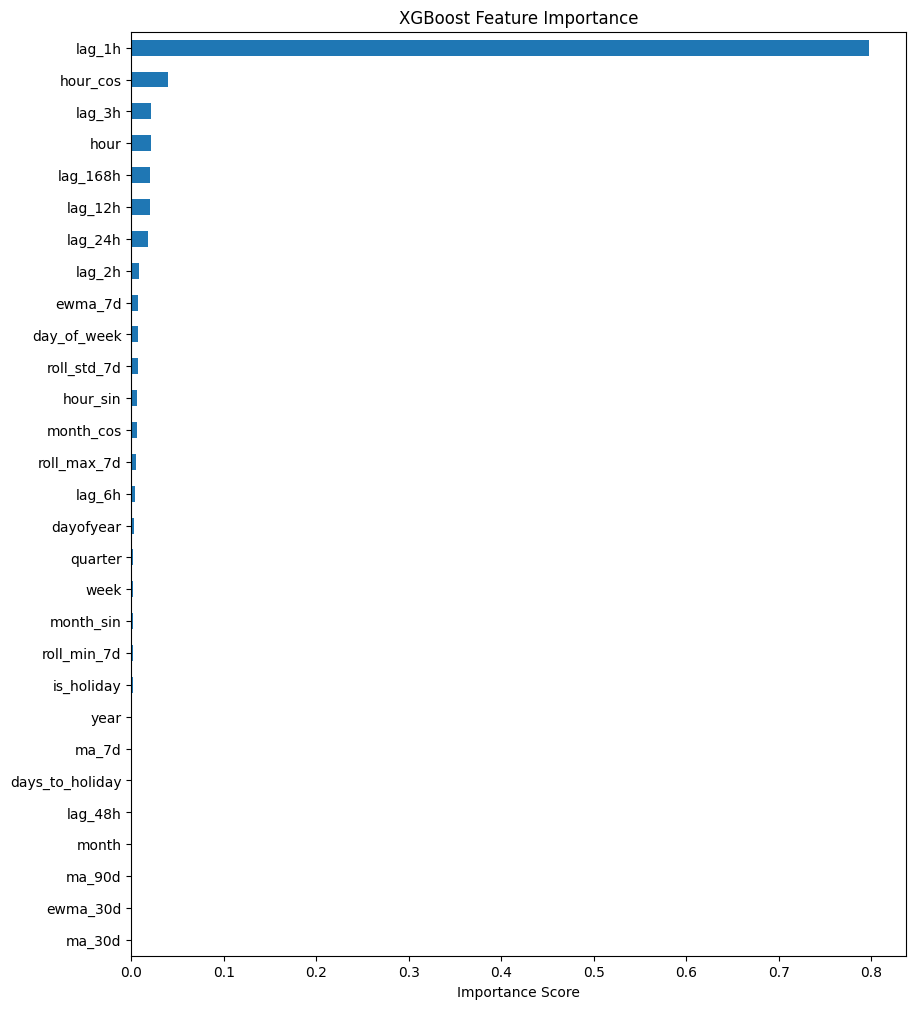

In [65]:
#Feature Importance
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind='barh', figsize=(10,12))
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.show()

Baseline - RMSE: 3926.79 | MAE: 2908.07
Full Model - RMSE: 496.28 | MAE: 382.23
RMSE Improvement: 3430.51
MAE Improvement: 2525.84


C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:149: UserWarning: Failed to determine whether UCVolumeDatasetSource can resolve source information for 'PJME_hourly.csv'. Exception: 
  return _dataset_source_registry.resolve(
C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:149: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integ

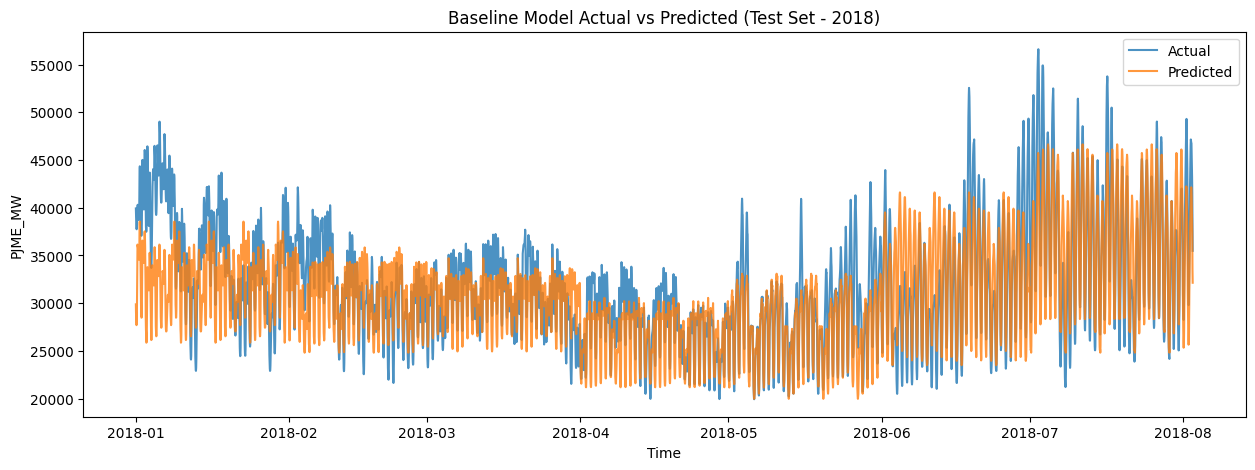

In [66]:
with mlflow.start_run(run_name="XGBoost_Baseline"):
    cv_baseline_xg    = data_baseline[data_baseline.index.year < 2018]
    test_baseline_xg  = data_baseline[data_baseline.index.year == 2018]

    X_baseline_train_xg = cv_baseline_xg.drop(columns=['PJME_MW'])
    y_baseline_train_xg = cv_baseline_xg['PJME_MW']
    X_baseline_test_xg  = test_baseline_xg.drop(columns=['PJME_MW'])
    y_baseline_test_xg  = test_baseline_xg['PJME_MW']

    scaler_baseline_xg = RobustScaler()
    X_baseline_train_xg_scaled = scaler_baseline_xg.fit_transform(X_baseline_train_xg)
    X_baseline_test_xg_scaled  = scaler_baseline_xg.transform(X_baseline_test_xg)

    model_baseline_xg = XGBRegressor()
    model_baseline_xg.fit(X_baseline_train_xg_scaled, y_baseline_train_xg)

    y_baseline_pred_xg = model_baseline_xg.predict(X_baseline_test_xg_scaled)

    rmse_test_xg_baseline = np.sqrt(mean_squared_error(y_baseline_test_xg, y_baseline_pred_xg))
    mae_test_xg_baseline  = mean_absolute_error(y_baseline_test_xg, y_baseline_pred_xg)

    print(f"Baseline - RMSE: {rmse_test_xg_baseline:.2f} | MAE: {mae_test_xg_baseline:.2f}")
    print(f"Full Model - RMSE: {rmse_test_xg:.2f} | MAE: {mae_test_xg:.2f}")
    print(f"RMSE Improvement: {rmse_test_xg_baseline - rmse_test_xg:.2f}")
    print(f"MAE Improvement: {mae_test_xg_baseline - mae_test_xg:.2f}")
    
    # MLflow Logging
    mlflow.log_param("model_type", "XGBoost_Baseline")
    # --- DATA TRACKING HERE ---
    mlflow.log_artifact("PJME_hourly.csv", artifact_path="raw_data")
    data_featured.head(100).to_csv("featured_data_sample.csv")
    mlflow.log_artifact("featured_data_sample.csv")

    # 1. Convert your pandas DataFrame into an MLflow Dataset
    dataset: PandasDataset = mlflow.data.from_pandas(data_featured, source="PJME_hourly.csv", name="Energy_Consumption_Featured")

    # 2. Log the dataset so it appears in that "Datasets" box
    mlflow.log_input(dataset, context="training")


    mlflow.log_metric("RMSE", rmse_test_xg_baseline)
    mlflow.log_metric("MAE", mae_test_xg_baseline)
    mlflow.xgboost.log_model(model_baseline_xg, "model")

    plt.figure(figsize=(15,5))
    plt.plot(y_baseline_test_xg.index, y_baseline_test_xg, label='Actual', alpha=0.8)
    plt.plot(y_baseline_test_xg.index, y_baseline_pred_xg, label='Predicted', alpha=0.8)
    plt.title('Baseline Model Actual vs Predicted (Test Set - 2018)')
    plt.xlabel('Time')
    plt.ylabel('PJME_MW')
    plt.legend()
    plt.show()


In [67]:
# Random Forrest with overfitting check

rmse_train_rf = []
mae_train_rf = []
rmse_val_rf = []
mae_val_rf = []

for fold, (X_train, X_val, y_train, y_val) in enumerate(splits):

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)

    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae_val = mean_absolute_error(y_val, y_val_pred)

    rmse_train_rf.append(rmse_train)
    mae_train_rf.append(mae_train)
    rmse_val_rf.append(rmse_val)
    mae_val_rf.append(mae_val)

    gap_rmse = rmse_val - rmse_train

    print(
        f"Fold {fold+1} | "
        f"RMSE_train_rf: {rmse_train:.2f} | MAE_train_rf: {mae_train:.2f} | "
        f"RMSE_val_rf: {rmse_val:.2f} | MAE_val_rf: {mae_val:.2f} | "
        f"Gap: {gap_rmse:.2f}"
    )

print("\nAverages:")
print(f"RMSE_train_rf: {np.mean(rmse_train_rf):.2f}")
print(f"MAE_train_rf:  {np.mean(mae_train_rf):.2f}")
print(f"RMSE_val_rf:   {np.mean(rmse_val_rf):.2f}")
print(f"MAE_val_rf:    {np.mean(mae_val_rf):.2f}")

Fold 1 | RMSE_train_rf: 294.83 | MAE_train_rf: 208.00 | RMSE_val_rf: 367.84 | MAE_val_rf: 266.67 | Gap: 73.01
Fold 2 | RMSE_train_rf: 297.31 | MAE_train_rf: 209.73 | RMSE_val_rf: 396.05 | MAE_val_rf: 278.64 | Gap: 98.74
Fold 3 | RMSE_train_rf: 297.92 | MAE_train_rf: 210.56 | RMSE_val_rf: 384.60 | MAE_val_rf: 276.48 | Gap: 86.68
Fold 4 | RMSE_train_rf: 301.90 | MAE_train_rf: 213.41 | RMSE_val_rf: 373.96 | MAE_val_rf: 272.91 | Gap: 72.06
Fold 5 | RMSE_train_rf: 306.29 | MAE_train_rf: 216.99 | RMSE_val_rf: 371.99 | MAE_val_rf: 269.65 | Gap: 65.70

Averages:
RMSE_train_rf: 299.65
MAE_train_rf:  211.74
RMSE_val_rf:   378.89
MAE_val_rf:    272.87


In [68]:
# Random Forest hyperparamter tuning with cross validation

rf_param_grid = [
    {"n_estimators": 20, "max_depth": 8},
    {"n_estimators": 50, "max_depth": 8},
    {"n_estimators": 20, "max_depth": 10},
    {"n_estimators": 50, "max_depth": 10},
    {"n_estimators": 20, "max_depth": 12},
    {"n_estimators": 50, "max_depth": 12},
]

rf_results = []

for params in rf_param_grid:
    rmse_vals = []
    mae_vals = []

    print(f"Testing params: {params}")

    for fold, (X_train, X_val, y_train, y_val) in enumerate(splits):
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        model = RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            random_state=42,
            n_jobs=1
        )

        model.fit(X_train_scaled, y_train)
        y_val_pred = model.predict(X_val_scaled)

        rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
        mae_val = mean_absolute_error(y_val, y_val_pred)

        rmse_vals.append(rmse_val)
        mae_vals.append(mae_val)

    avg_rmse = np.mean(rmse_vals)
    avg_mae = np.mean(mae_vals)

    rf_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "avg_rmse": avg_rmse,
        "avg_mae": avg_mae
    })



best_rf = min(rf_results, key=lambda x: x['avg_rmse'])



Testing params: {'n_estimators': 20, 'max_depth': 8}
Testing params: {'n_estimators': 50, 'max_depth': 8}
Testing params: {'n_estimators': 20, 'max_depth': 10}
Testing params: {'n_estimators': 50, 'max_depth': 10}
Testing params: {'n_estimators': 20, 'max_depth': 12}
Testing params: {'n_estimators': 50, 'max_depth': 12}


In [69]:
rf_results_df = pd.DataFrame(rf_results).sort_values(by="avg_rmse")
rf_results_df

,n_estimators,max_depth,avg_rmse,avg_mae
5,50,12,378.890630,272.868963
4,20,12,382.883515,275.977262
3,50,10,464.926540,342.753711
2,20,10,468.657776,345.520798
1,50,8,617.360453,468.338139
0,20,8,620.859185,470.857656


C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:149: UserWarning: Failed to determine whether UCVolumeDatasetSource can resolve source information for 'PJME_hourly.csv'. Exception: 
  return _dataset_source_registry.resolve(
C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:149: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integ

RMSE_test_rf: 391.79
MAE_test_rf: 288.81


2026/04/24 19:58:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


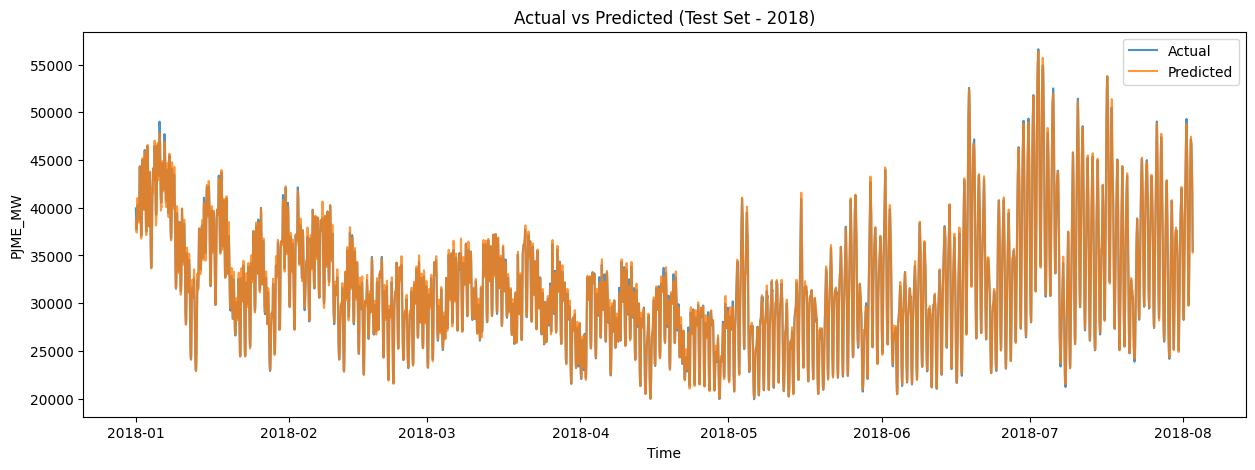

In [70]:
with mlflow.start_run(run_name="RandomForest_Final_Model"):
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_scaled, y)

    # Test
    X_test_scaled = scaler.transform(X_test)
    y_test_pred = model.predict(X_test_scaled)

    # --- DATA TRACKING HERE ---
    mlflow.log_artifact("PJME_hourly.csv", artifact_path="raw_data")
    data_featured.head(100).to_csv("featured_data_sample.csv")
    mlflow.log_artifact("featured_data_sample.csv")

    # 1. Convert your pandas DataFrame into an MLflow Dataset
    dataset: PandasDataset = mlflow.data.from_pandas(data_featured, source="PJME_hourly.csv", name="Energy_Consumption_Featured")

    # 2. Log the dataset so it appears in that "Datasets" box
    mlflow.log_input(dataset, context="training")



    # Metrics
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)

    print(f"RMSE_test_rf: {rmse_test:.2f}")
    print(f"MAE_test_rf: {mae_test:.2f}")

    # MLflow Logging
    mlflow.log_params({
        "n_estimators": model.n_estimators,
        "max_depth": model.max_depth
    })
    mlflow.log_metric("RMSE", rmse_test)
    mlflow.log_metric("MAE", mae_test)
    mlflow.sklearn.log_model(model, "model")

    # Plot Actual vs Predicted (Test - 2018)
    plt.figure(figsize=(15,5))
    plt.plot(y_test.index, y_test, label='Actual', alpha=0.8)
    plt.plot(y_test.index, y_test_pred, label='Predicted', alpha=0.8)
    plt.title('Actual vs Predicted (Test Set - 2018)')
    plt.xlabel('Time')
    plt.ylabel('PJME_MW')
    plt.legend()
    plt.show()


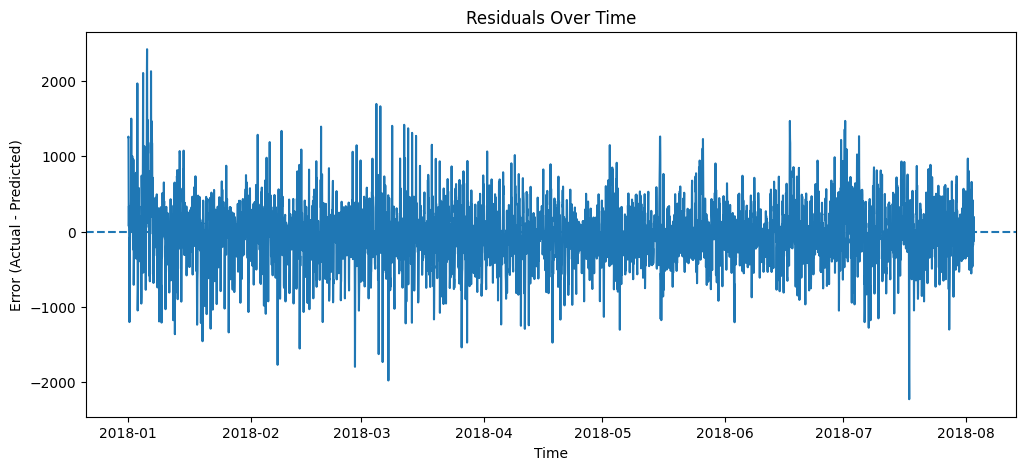

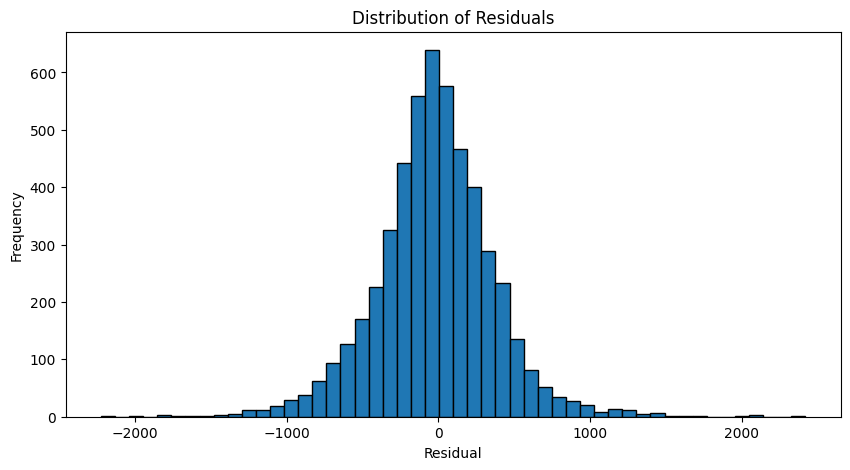

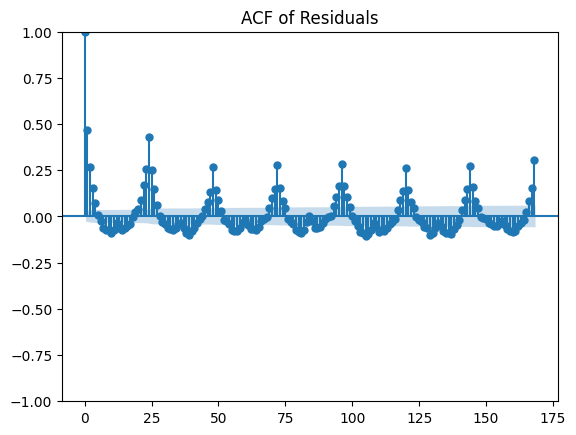

In [71]:
#Residual Analysis for Random Forest
residuals = y_test - y_test_pred

# Time series plot
plt.figure(figsize=(12,5))
plt.plot(residuals.index, residuals)
plt.axhline(0, linestyle='--')

plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error (Actual - Predicted)")

plt.show()


# Histogram of residuals
plt.figure(figsize=(10,5))
plt.hist(residuals.dropna(), bins=50, edgecolor='black')

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

#ACF plot
plot_acf(residuals.dropna(), lags=168)  # 48 hrs to catch daily patterns
plt.title("ACF of Residuals")
plt.show()

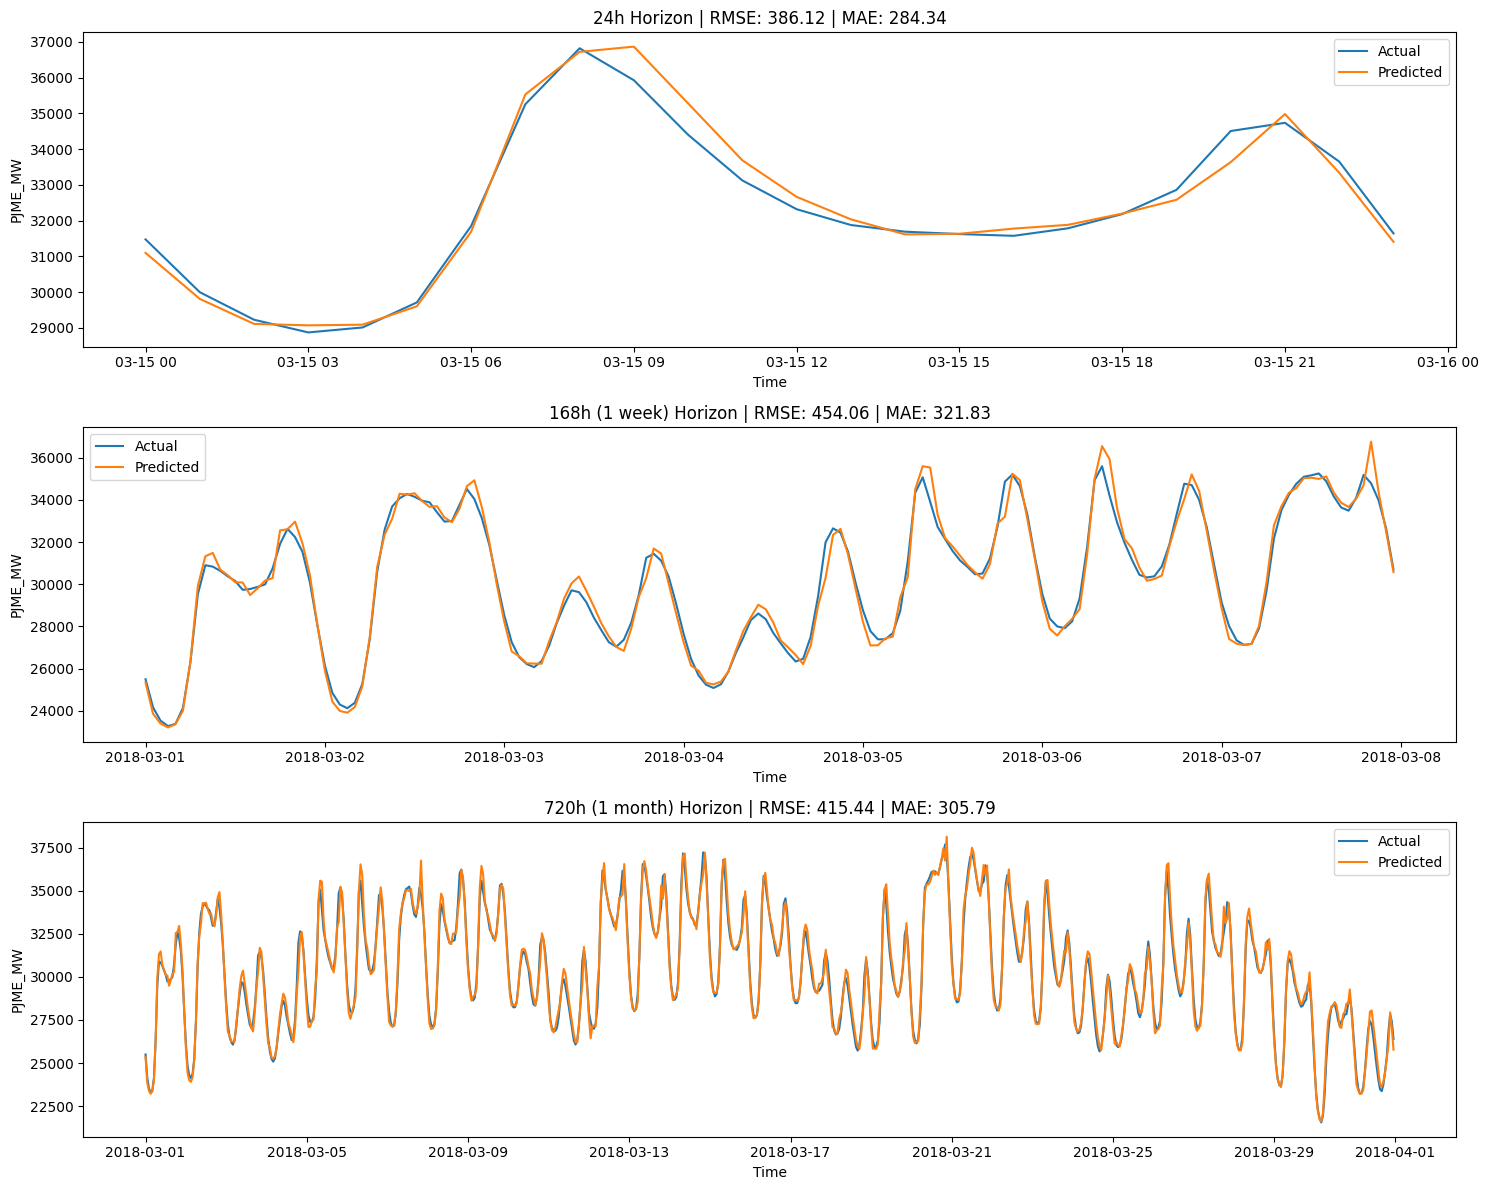

In [72]:
#define horizons

fig, axs = plt.subplots(3, 1, figsize=(15, 12))

# 24h: full day March 15
mask_24h = (y_test.index >= '2018-03-15') & (y_test.index < '2018-03-16')
# 168h: full week March 1-8
mask_168h = (y_test.index >= '2018-03-01') & (y_test.index < '2018-03-08')
# 720h: full month of March
mask_720h = (y_test.index >= '2018-03-01') & (y_test.index < '2018-04-01')

masks = [('24h', mask_24h), ('168h (1 week)', mask_168h), ('720h (1 month)', mask_720h)]

for ax, (name, mask) in zip(axs, masks):
    actual = y_test[mask]
    pred = y_test_pred[mask]
    
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    
    ax.plot(actual.index, actual.values, label='Actual')
    ax.plot(actual.index, pred, label='Predicted')
    ax.set_title(f'{name} Horizon | RMSE: {rmse:.2f} | MAE: {mae:.2f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('PJME_MW')
    ax.legend()

plt.tight_layout()
plt.show()

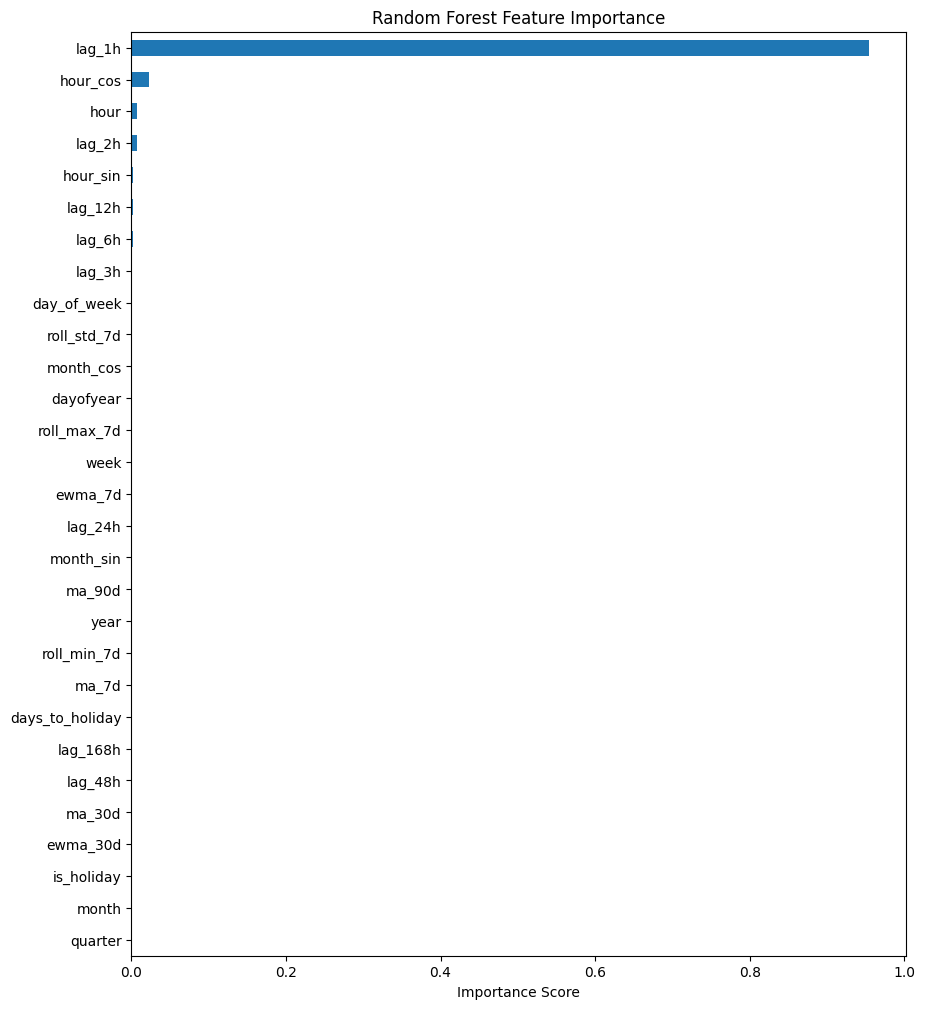

In [73]:
#Feature Importance
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind='barh', figsize=(10,12))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.show()

Baseline - RMSE: 4018.28 | MAE: 2982.66
Full Model - RMSE: 391.79 | MAE: 288.81
RMSE Improvement: 3626.49
MAE Improvement: 2693.85


C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:149: UserWarning: Failed to determine whether UCVolumeDatasetSource can resolve source information for 'PJME_hourly.csv'. Exception: 
  return _dataset_source_registry.resolve(
C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:149: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integ

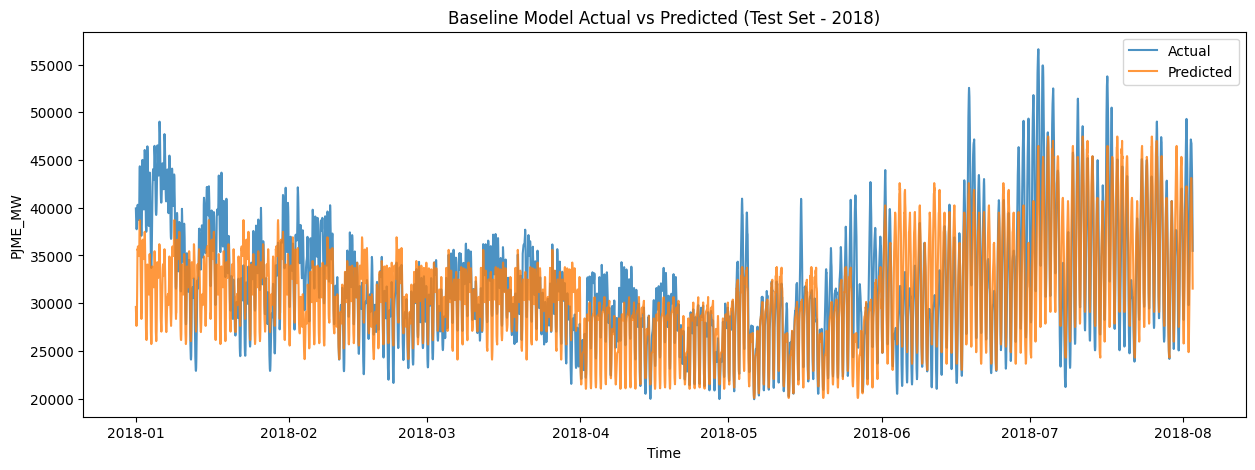

In [74]:
with mlflow.start_run(run_name="RandomForest_Baseline"):
    cv_baseline_rf    = data_baseline[data_baseline.index.year < 2018]
    test_baseline_rf  = data_baseline[data_baseline.index.year == 2018]

    X_baseline_train_rf = cv_baseline_rf.drop(columns=['PJME_MW'])
    y_baseline_train_rf = cv_baseline_rf['PJME_MW']
    X_baseline_test_rf  = test_baseline_rf.drop(columns=['PJME_MW'])
    y_baseline_test_rf  = test_baseline_rf['PJME_MW']

    scaler_baseline_rf = RobustScaler()
    X_baseline_train_rf_scaled = scaler_baseline_rf.fit_transform(X_baseline_train_rf)
    X_baseline_test_rf_scaled  = scaler_baseline_rf.transform(X_baseline_test_rf)

    model_baseline_rf = RandomForestRegressor()
    model_baseline_rf.fit(X_baseline_train_rf_scaled, y_baseline_train_rf)

    y_baseline_pred_rf = model_baseline_rf.predict(X_baseline_test_rf_scaled)

    rmse_test_rf_baseline = np.sqrt(mean_squared_error(y_baseline_test_rf, y_baseline_pred_rf))
    mae_test_rf_baseline  = mean_absolute_error(y_baseline_test_rf, y_baseline_pred_rf)

    print(f"Baseline - RMSE: {rmse_test_rf_baseline:.2f} | MAE: {mae_test_rf_baseline:.2f}")
    print(f"Full Model - RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")
    print(f"RMSE Improvement: {rmse_test_rf_baseline - rmse_test:.2f}")
    print(f"MAE Improvement: {mae_test_rf_baseline - mae_test:.2f}")

    # MLflow Logging
    mlflow.log_param("model_type", "RandomForest_Baseline")
    # --- DATA TRACKING HERE ---
    mlflow.log_artifact("PJME_hourly.csv", artifact_path="raw_data")
    data_featured.head(100).to_csv("featured_data_sample.csv")
    mlflow.log_artifact("featured_data_sample.csv")

    # 1. Convert your pandas DataFrame into an MLflow Dataset
    dataset: PandasDataset = mlflow.data.from_pandas(data_featured, source="PJME_hourly.csv", name="Energy_Consumption_Featured")

    # 2. Log the dataset so it appears in that "Datasets" box
    mlflow.log_input(dataset, context="training")


    mlflow.log_metric("RMSE", rmse_test_rf_baseline)
    mlflow.log_metric("MAE", mae_test_rf_baseline)
    mlflow.sklearn.log_model(model_baseline_rf, "model")

    plt.figure(figsize=(15,5))
    plt.plot(y_baseline_test_rf.index, y_baseline_test_rf, label='Actual', alpha=0.8)
    plt.plot(y_baseline_test_rf.index, y_baseline_pred_rf, label='Predicted', alpha=0.8)
    plt.title('Baseline Model Actual vs Predicted (Test Set - 2018)')
    plt.xlabel('Time')
    plt.ylabel('PJME_MW')
    plt.legend()
    plt.show()
